<a href="https://colab.research.google.com/github/Juli-Kareva/Fraud-detection-MDS/blob/main/Fraud_Detection_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Technical Part

In [110]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

### Загрузим библиотеки

In [111]:
%pip install opendatasets

import opendatasets as od
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [112]:
SEED = 1208
np.random.seed(SEED)

### Загрузим датасет

In [113]:
#upload dataset from kaggle
cwd = os.getcwd()

od.download("https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/data", path=cwd, force=True)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: c
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022


100%|██████████| 532M/532M [00:08<00:00, 64.7MB/s]


In [114]:
data_pdf = pd.read_csv("/content/bank-account-fraud-dataset-neurips-2022/Base.csv")
data_pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

### Создадим доп функции

In [115]:
# поиск выбросов по алгоритму
def find_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

## Analysis of dataset

###Зависимая переменная

Прежде чем переходить к анализу признаков, оценим распределение целевой переменной `fraud_bool`.
Дисбаланс классов — ключевая характеристика задачи, которая влияет на все последующие решения:
выбор метрики, стратегию сэмплинга и архитектуру модели.

In [116]:
fraud_counts = data_pdf['fraud_bool'].value_counts()
fraud_rate   = data_pdf['fraud_bool'].mean()
total        = len(data_pdf)

print(f"  Всего записей:          {total:>10,}")
print(f"  Легитимных (0):         {fraud_counts[0]:>10,}  ({fraud_counts[0]/total:.2%})")
print(f"  Фродовых   (1):         {fraud_counts[1]:>10,}  ({fraud_counts[1]/total:.2%})")
print(f"  Соотношение fraud:legit  1 : {fraud_counts[0]/fraud_counts[1]:.0f}")

  Всего записей:           1,000,000
  Легитимных (0):            988,971  (98.90%)
  Фродовых   (1):             11,029  (1.10%)
  Соотношение fraud:legit  1 : 90


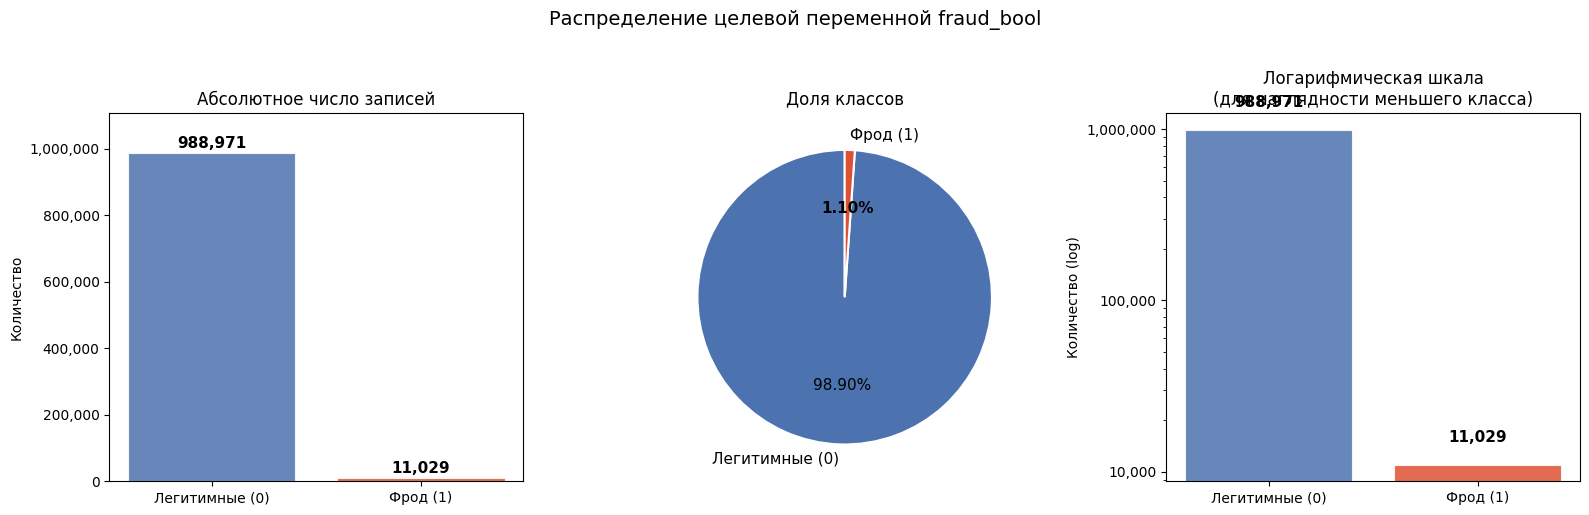

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Распределение целевой переменной fraud_bool', fontsize=14, y=1.02)

COLORS = ['#4C72B0', '#DD5133']

#Bar chart с абсолютными числами
bars = axes[0].bar(
    ['Легитимные (0)', 'Фрод (1)'],
    fraud_counts.values,
    color=COLORS, alpha=0.85, edgecolor='white', linewidth=0.8
)
axes[0].set_title('Абсолютное число записей')
axes[0].set_ylabel('Количество')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_ylim(0, fraud_counts[0] * 1.12)

#Pie chart с процентами
wedges, texts, autotexts = axes[1].pie(
    fraud_counts.values,
    labels=['Легитимные (0)', 'Фрод (1)'],
    colors=COLORS,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=11)
)
autotexts[1].set_fontweight('bold')
axes[1].set_title('Доля классов')

#Log-scale bar — чтобы фрод был виден
axes[2].bar(
    ['Легитимные (0)', 'Фрод (1)'],
    fraud_counts.values,
    color=COLORS, alpha=0.85, edgecolor='white', linewidth=0.8
)
axes[2].set_yscale('log')
axes[2].set_title('Логарифмическая шкала\n(для наглядности меньшего класса)')
axes[2].set_ylabel('Количество (log)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(axes[2].patches, fraud_counts.values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        val * 1.3,
        f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

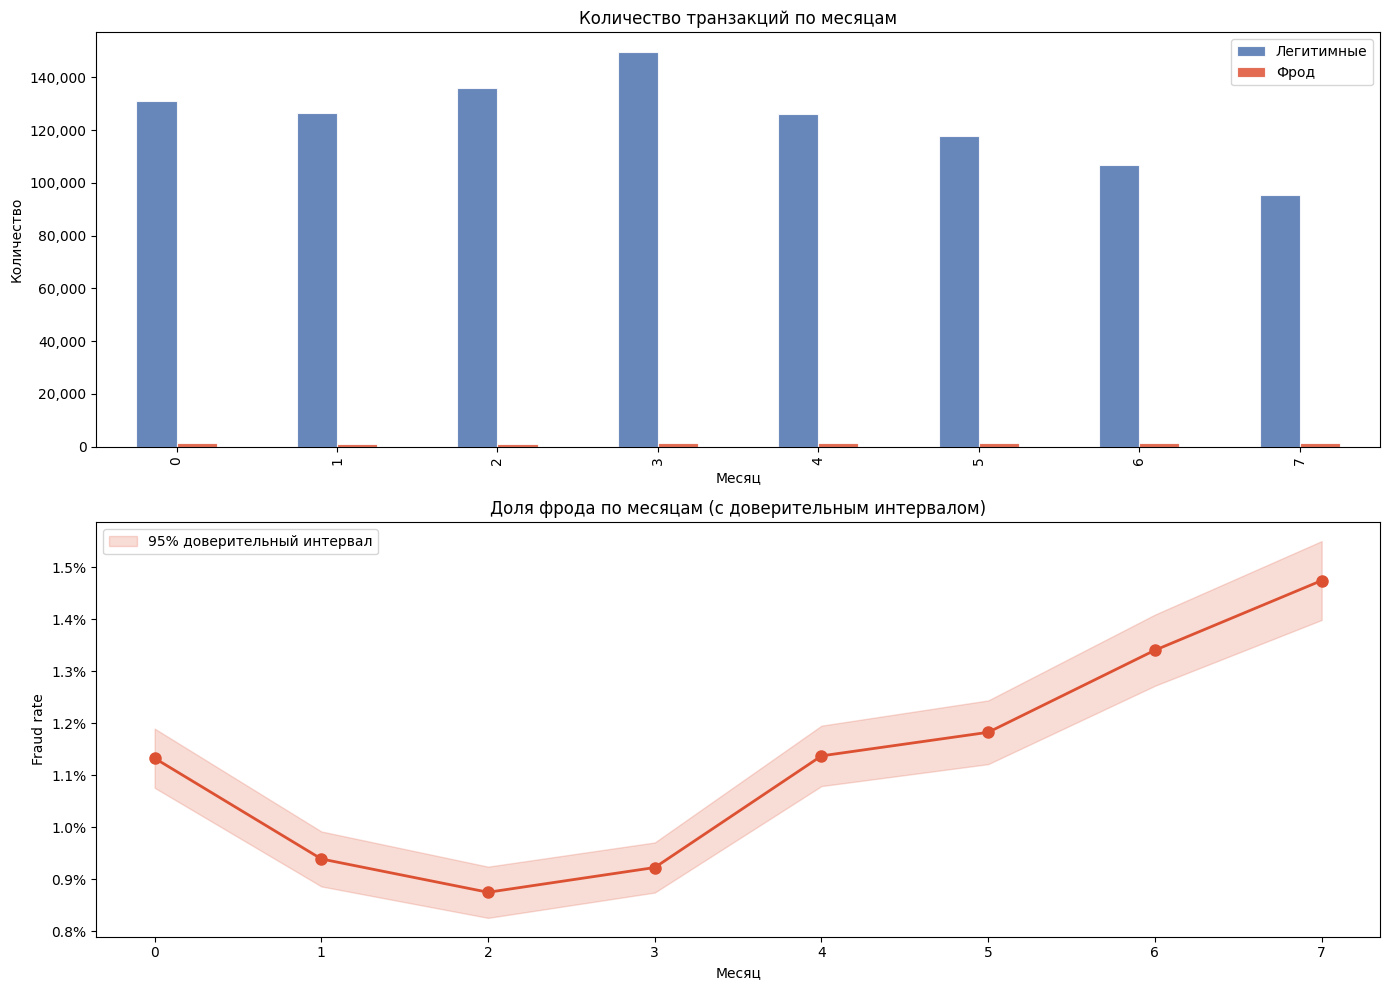

In [118]:
#Let's check for changes of fraud cases in time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

#Абсолютное число фродов и легитимных по месяцам
monthly_counts = data_pdf.groupby(['month', 'fraud_bool']).size().unstack()
monthly_counts.plot(
    kind='bar', ax=axes[0],
    color=['#4C72B0', '#DD5133'], alpha=0.85,
    edgecolor='white', linewidth=0.8
)
axes[0].set_title('Количество транзакций по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Количество')
axes[0].legend(['Легитимные', 'Фрод'])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

#Доля фрода по месяцам + доверительный интервал
monthly = data_pdf.groupby('month')['fraud_bool'].agg(['mean', 'count'])
monthly['se'] = np.sqrt(
    monthly['mean'] * (1 - monthly['mean']) / monthly['count']
)

axes[1].plot(monthly.index, monthly['mean'],
             marker='o', color='#DD5133', linewidth=2, markersize=8)
axes[1].fill_between(
    monthly.index,
    monthly['mean'] - 1.96 * monthly['se'],
    monthly['mean'] + 1.96 * monthly['se'],
    alpha=0.2, color='#DD5133', label='95% доверительный интервал'
)
axes[1].set_title('Доля фрода по месяцам (с доверительным интервалом)')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Fraud rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].legend()

plt.tight_layout()
plt.show()

###Независимые переменные

In [119]:
data_pdf.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [120]:
# Basic analysis for duplicates
duplicates = data_pdf.duplicated()
number_of_duplicates = duplicates.sum()
print(f"Количество полных дубликатов в датасете: {number_of_duplicates}")

Количество полных дубликатов в датасете: 0


In [121]:
# Checking for nulls
print(data_pdf.isnull().sum())

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

In [122]:
# найдем выбросы
numeric_cols  = data_pdf.dtypes[data_pdf.dtypes.isin(['int64', 'float64'])].index.tolist()
for x in numeric_cols:
  outl = find_outliers(data_pdf, f'{x}')
  print(f'Выбросы по {x}: {len(outl)}')

Выбросы по fraud_bool: 11029
Выбросы по income: 0
Выбросы по name_email_similarity: 0
Выбросы по prev_address_months_count: 157320
Выбросы по current_address_months_count: 41001
Выбросы по customer_age: 1373
Выбросы по days_since_request: 94834
Выбросы по intended_balcon_amount: 222702
Выбросы по zip_count_4w: 59871
Выбросы по velocity_6h: 9005
Выбросы по velocity_24h: 2917
Выбросы по velocity_4w: 0
Выбросы по bank_branch_count_8w: 175243
Выбросы по date_of_birth_distinct_emails_4w: 9734
Выбросы по credit_risk_score: 8729
Выбросы по email_is_free: 0
Выбросы по phone_home_valid: 0
Выбросы по phone_mobile_valid: 110324
Выбросы по bank_months_count: 0
Выбросы по has_other_cards: 222988
Выбросы по proposed_credit_limit: 241742
Выбросы по foreign_request: 25242
Выбросы по session_length_in_minutes: 78789
Выбросы по keep_alive_session: 0
Выбросы по device_distinct_emails_8w: 31933
Выбросы по device_fraud_count: 0
Выбросы по month: 0


In [123]:
data_pdf.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


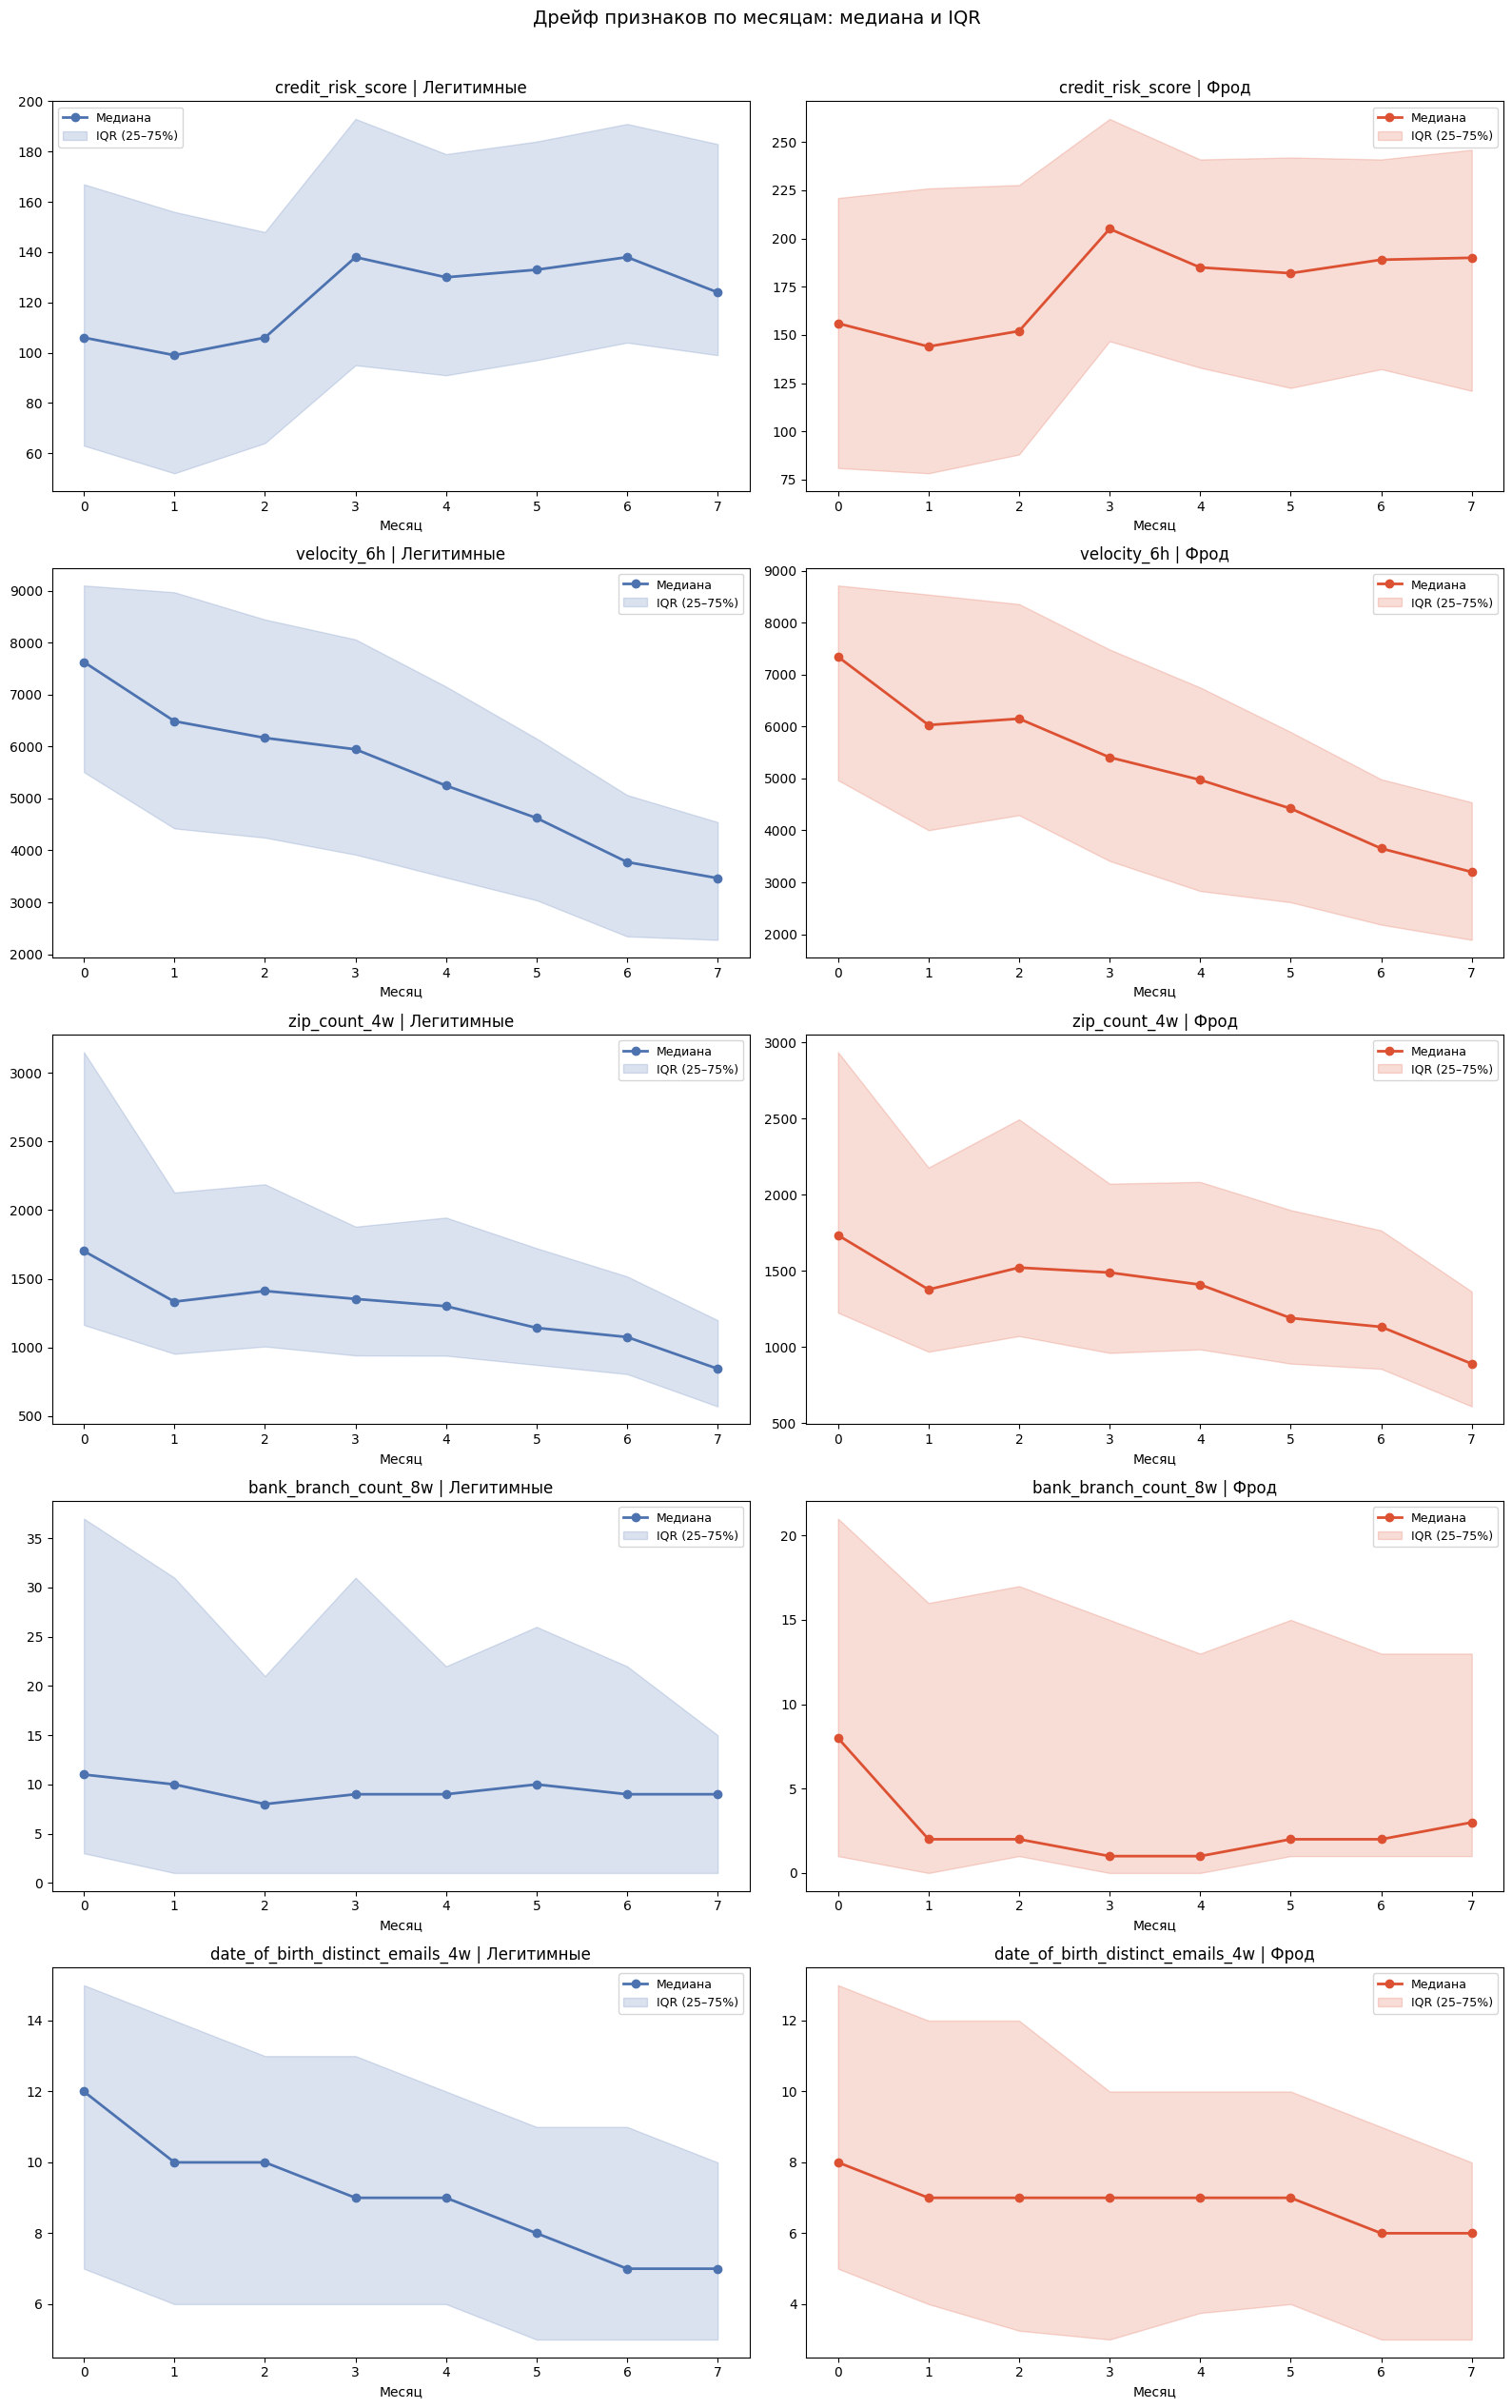

In [124]:
#посмотрим на дрейф ключевых признаков
key_features = [
    'credit_risk_score',
    'velocity_6h',
    'zip_count_4w',
    'bank_branch_count_8w',
    'date_of_birth_distinct_emails_4w'
]

fig, axes = plt.subplots(len(key_features), 2, figsize=(16, 5 * len(key_features)))
fig.suptitle('Дрейф признаков по месяцам: медиана и IQR', fontsize=14, y=1.01)

for i, feat in enumerate(key_features):
    for j, (fraud_val, label, color) in enumerate([
        (0, 'Легитимные', '#4C72B0'),
        (1, 'Фрод',       '#DD5133')
    ]):
        ax = axes[i][j]
        subset = data_pdf[data_pdf['fraud_bool'] == fraud_val]

        monthly_stats = subset.groupby('month')[feat].agg([
            ('median', 'median'),
            ('q25',    lambda x: x.quantile(0.25)),
            ('q75',    lambda x: x.quantile(0.75))
        ])

        ax.plot(monthly_stats.index, monthly_stats['median'],
                marker='o', color=color, linewidth=2, label='Медиана')
        ax.fill_between(
            monthly_stats.index,
            monthly_stats['q25'],
            monthly_stats['q75'],
            alpha=0.2, color=color, label='IQR (25–75%)'
        )
        ax.set_title(f'{feat} | {label}')
        ax.set_xlabel('Месяц')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

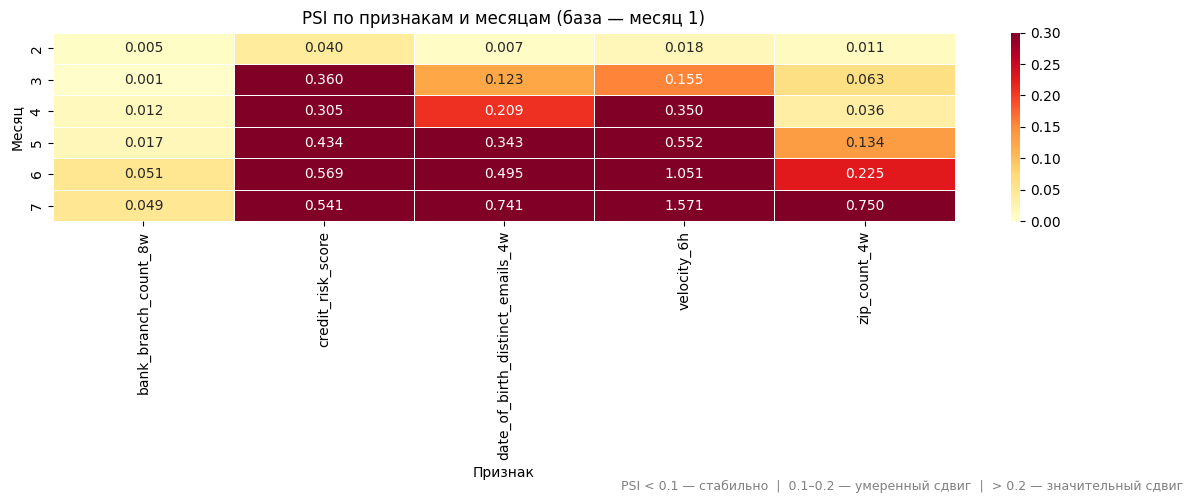

Признаки со значительным дрейфом (PSI > 0.2 хотя бы в одном месяце):
['credit_risk_score', 'date_of_birth_distinct_emails_4w', 'velocity_6h', 'zip_count_4w']

Признаки с умеренным дрейфом (PSI 0.1–0.2):
['date_of_birth_distinct_emails_4w', 'velocity_6h', 'zip_count_4w']


In [125]:
#посмотрим на PSI
def calc_psi(base, current, bins=10):
    breakpoints = np.linspace(
        min(base.min(), current.min()),
        max(base.max(), current.max()),
        bins + 1
    )
    base_pct    = np.histogram(base,    bins=breakpoints)[0] / len(base)
    current_pct = np.histogram(current, bins=breakpoints)[0] / len(current)
    base_pct    = np.where(base_pct    == 0, 1e-6, base_pct)
    current_pct = np.where(current_pct == 0, 1e-6, current_pct)
    return np.sum((current_pct - base_pct) * np.log(current_pct / base_pct))

# месяц 1 — база, остальные сравниваем с ней
base_month = data_pdf[data_pdf['month'] == 1]
psi_results = []

for month in range(2, data_pdf['month'].max() + 1):
    current_month = data_pdf[data_pdf['month'] == month]
    for feat in key_features:
        psi = calc_psi(
            base_month[feat].dropna(),
            current_month[feat].dropna()
        )
        psi_results.append({
            'month':   month,
            'feature': feat,
            'PSI':     round(psi, 4)
        })

psi_df = pd.DataFrame(psi_results).pivot(
    index='month', columns='feature', values='PSI'
)

# визуализация PSI как heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(
    psi_df,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0, vmax=0.3
)
plt.title('PSI по признакам и месяцам (база — месяц 1)')
plt.xlabel('Признак')
plt.ylabel('Месяц')

# добавим легенду порогов
plt.figtext(0.99, 0.01,
    'PSI < 0.1 — стабильно  |  0.1–0.2 — умеренный сдвиг  |  > 0.2 — значительный сдвиг',
    ha='right', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

# итоговый вывод по признакам
print("Признаки со значительным дрейфом (PSI > 0.2 хотя бы в одном месяце):")
drifted = psi_df.columns[(psi_df > 0.2).any()].tolist()
print(drifted if drifted else "Не обнаружено")

print("\nПризнаки с умеренным дрейфом (PSI 0.1–0.2):")
moderate = psi_df.columns[((psi_df > 0.1) & (psi_df <= 0.2)).any()].tolist()
print(moderate if moderate else "Не обнаружено")

## Разделение на train, test и oot
train и test будут использоваться для обучения и тестирования модели.
oot будет использоваться для тестирования прогнозной способности модели.

oot - будут 2 последних месяца в выборке
train - 0-4 месяц
test - 5 месяц

In [126]:
df_oot = data_pdf[data_pdf['month'] > 5]
df_train = data_pdf[data_pdf['month'] <= 4]
df_test = data_pdf[data_pdf['month'] == 5]

In [127]:
df_oot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205011 entries, 794989 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fraud_bool                        205011 non-null  int64  
 1   income                            205011 non-null  float64
 2   name_email_similarity             205011 non-null  float64
 3   prev_address_months_count         205011 non-null  int64  
 4   current_address_months_count      205011 non-null  int64  
 5   customer_age                      205011 non-null  int64  
 6   days_since_request                205011 non-null  float64
 7   intended_balcon_amount            205011 non-null  float64
 8   payment_type                      205011 non-null  object 
 9   zip_count_4w                      205011 non-null  int64  
 10  velocity_6h                       205011 non-null  float64
 11  velocity_24h                      205011 non-null  f

In [128]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 675666 entries, 0 to 675665
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fraud_bool                        675666 non-null  int64  
 1   income                            675666 non-null  float64
 2   name_email_similarity             675666 non-null  float64
 3   prev_address_months_count         675666 non-null  int64  
 4   current_address_months_count      675666 non-null  int64  
 5   customer_age                      675666 non-null  int64  
 6   days_since_request                675666 non-null  float64
 7   intended_balcon_amount            675666 non-null  float64
 8   payment_type                      675666 non-null  object 
 9   zip_count_4w                      675666 non-null  int64  
 10  velocity_6h                       675666 non-null  float64
 11  velocity_24h                      675666 non-null  float6

In [129]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119323 entries, 675666 to 794988
Data columns (total 32 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   fraud_bool                        119323 non-null  int64  
 1   income                            119323 non-null  float64
 2   name_email_similarity             119323 non-null  float64
 3   prev_address_months_count         119323 non-null  int64  
 4   current_address_months_count      119323 non-null  int64  
 5   customer_age                      119323 non-null  int64  
 6   days_since_request                119323 non-null  float64
 7   intended_balcon_amount            119323 non-null  float64
 8   payment_type                      119323 non-null  object 
 9   zip_count_4w                      119323 non-null  int64  
 10  velocity_6h                       119323 non-null  float64
 11  velocity_24h                      119323 non-null  f

## Очистка данных

сфокусируемся на train данных

Так как данные несбалансированные, будем анализировать данные отдельно для фродовых строк и не-фродовых. Чтобы анализ пустышек\выбросов был более честным

In [130]:
df_train['fraud_bool'].value_counts()

,count
fraud_bool,
0,668926
1,6740


/tmp/ipykernel_1625/3903667522.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_1625/3903667522.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_1625/3903667522.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_1625/3903667522.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_1625/3903667522.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

IndexError: index 5 is out of bounds for axis 0 with size 5

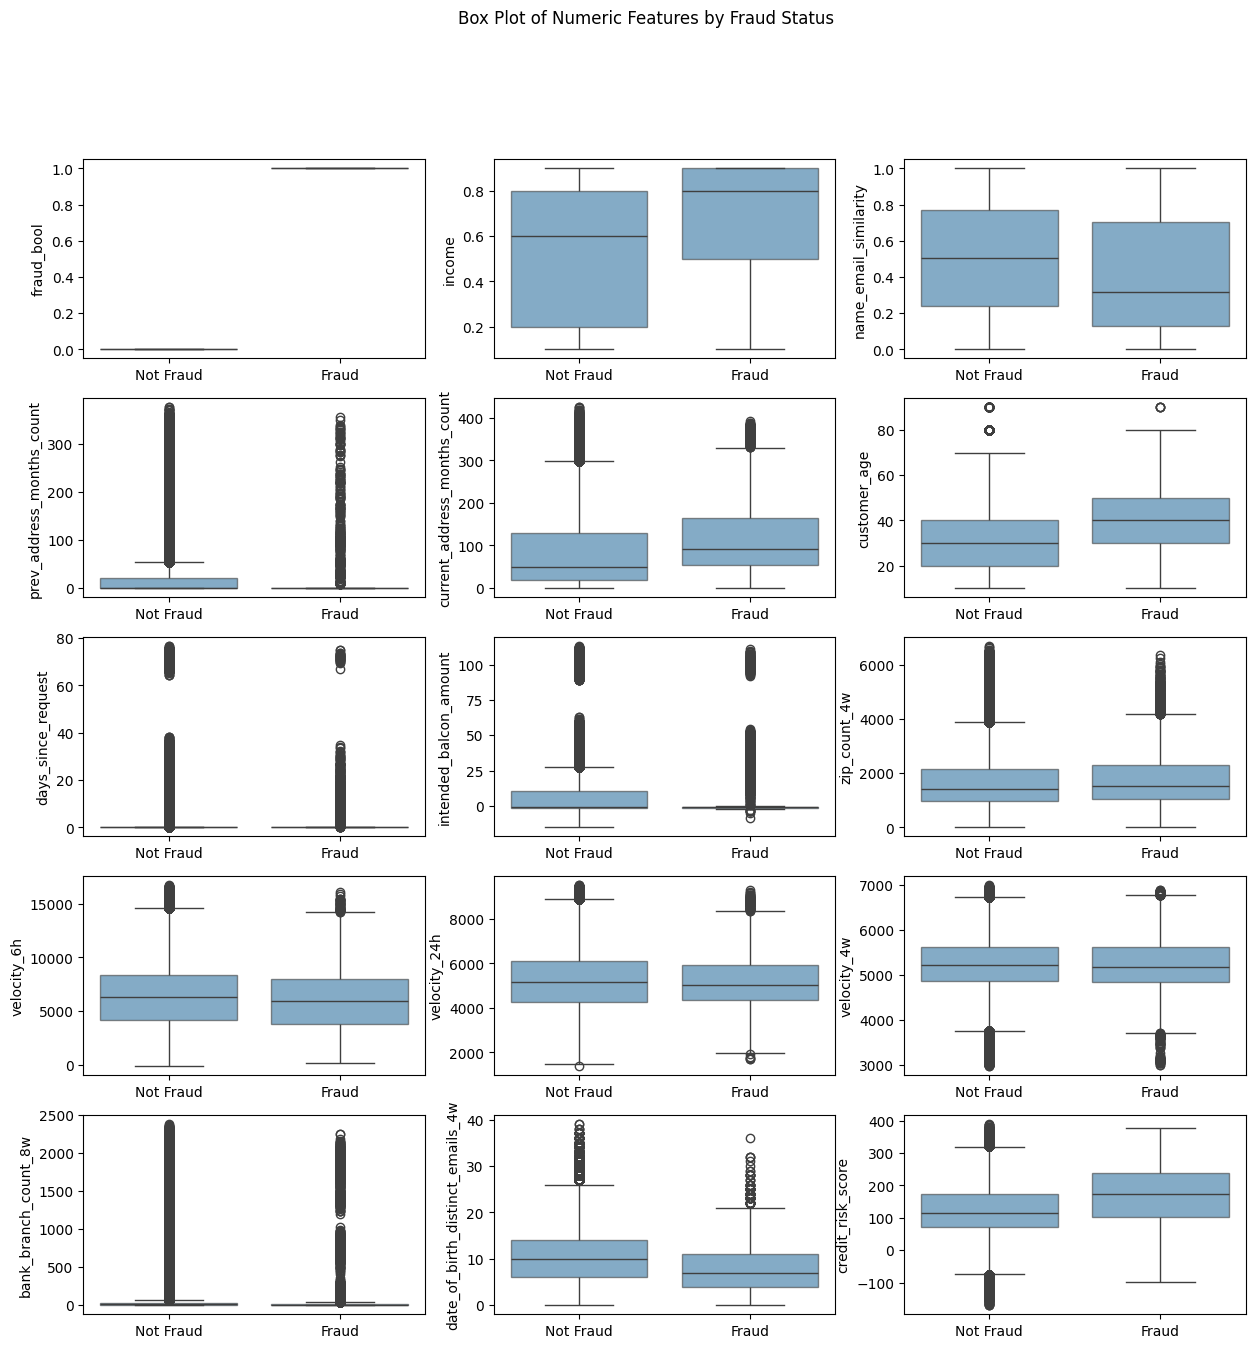

In [132]:
# Create a grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 15))

# Add a title to the figure
fig.suptitle('Box Plot of Numeric Features by Fraud Status')

# Loop through the numeric features and plot a box plot for each feature
num_columns = list(df_train.select_dtypes(include=['float64', 'int64']).columns)

for i, feature in enumerate(num_columns):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df_train, x='fraud_bool', y=feature, ax=ax, boxprops=dict(alpha=.6))
    ax.set_xlabel('')
    ax.set_ylabel(feature)
    ax.set_xticklabels(['Not Fraud', 'Fraud'])

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

Рассмотрим более подробно переменные с большим количеством выбросов

### prev_address_months_count
мы знаем, что (-1) здесь означает незаполненные данные

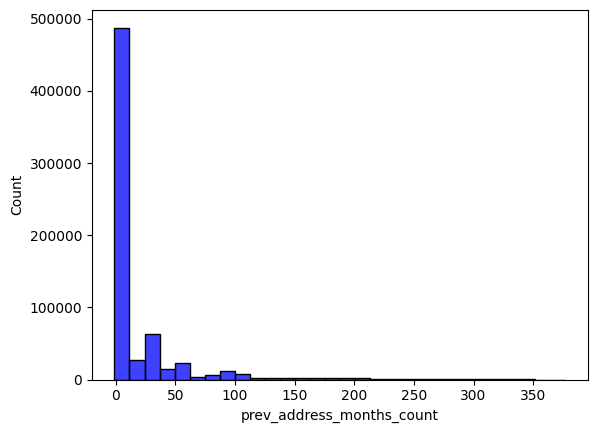

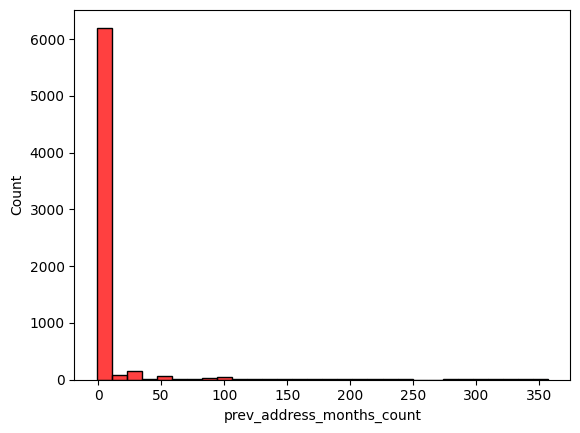

In [133]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['prev_address_months_count'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['prev_address_months_count'], bins=30, color='red')
plt.show()

In [134]:
top_5 = df_train[df_train['fraud_bool'] == 0]['prev_address_months_count'].value_counts().head(5)
print(top_5)

prev_address_months_count
-1     463737
 11      8838
 10      8264
 27      7733
 28      7717
Name: count, dtype: int64


In [135]:
top_5 = df_train[df_train['fraud_bool'] == 1]['prev_address_months_count'].value_counts().head(5)
print(top_5)

prev_address_months_count
-1     6170
 11      26
 28      23
 31      19
 10      18
Name: count, dtype: int64


In [136]:
#Так как процент заполненности более 95% в обеих подгруппах - заменим -1 на Nan
df_train['prev_address_months_count'] = df_train['prev_address_months_count'].replace({-1: np.nan})

/tmp/ipykernel_1625/3796057027.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['prev_address_months_count'] = df_train['prev_address_months_count'].replace({-1: np.nan})


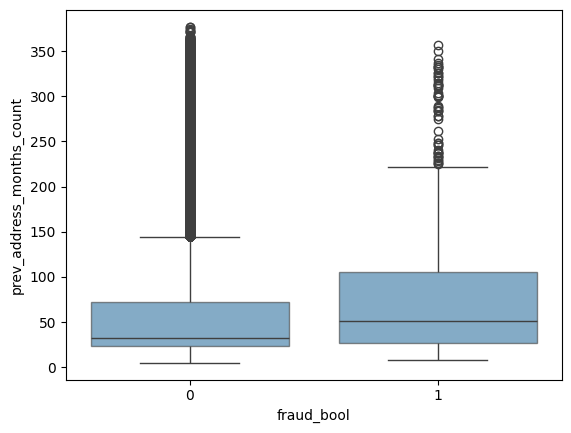

In [137]:
sns.boxplot(data=df_train, x='fraud_bool', y='prev_address_months_count', boxprops=dict(alpha=.6))
plt.show()

In [138]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'prev_address_months_count')
print(f'Выбросы по prev_address_months_count NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'prev_address_months_count')
print(f'Выбросы по prev_address_months_count fraud: {len(outl)}')

Выбросы по prev_address_months_count NOT fraud: 18953
Выбросы по prev_address_months_count fraud: 56


In [139]:
df_train[df_train['fraud_bool'] == 0]['prev_address_months_count'].info()

df_train[df_train['fraud_bool'] == 1]['prev_address_months_count'].info()

<class 'pandas.core.series.Series'>
Index: 668926 entries, 0 to 675665
Series name: prev_address_months_count
Non-Null Count   Dtype  
--------------   -----  
205189 non-null  float64
dtypes: float64(1)
memory usage: 10.2 MB
<class 'pandas.core.series.Series'>
Index: 6740 entries, 43 to 675548
Series name: prev_address_months_count
Non-Null Count  Dtype  
--------------  -----  
570 non-null    float64
dtypes: float64(1)
memory usage: 105.3 KB


In [140]:
df_train['prev_address_months_count'].info()

<class 'pandas.core.series.Series'>
Index: 675666 entries, 0 to 675665
Series name: prev_address_months_count
Non-Null Count   Dtype  
--------------   -----  
205759 non-null  float64
dtypes: float64(1)
memory usage: 10.3 MB


In [141]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение по трайн выборке, чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['prev_address_months_count'].quantile(0.25)
Q3 = df_train['prev_address_months_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['prev_address_months_count'] >= lower_bound) & (df_train['prev_address_months_count'] <= upper_bound)]['prev_address_months_count']

median_value = non_outliers.median()

df_train['prev_address_months_count_clean'] = np.where(
    (df_train['prev_address_months_count'] < lower_bound) | (df_train['prev_address_months_count'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['prev_address_months_count']                                                  # Иначе оставить как есть
)

/tmp/ipykernel_1625/3611805785.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['prev_address_months_count_clean'] = np.where(


In [142]:
#заменим также в тест и оот
df_test['prev_address_months_count_clean'] = np.where(
    (df_test['prev_address_months_count'] < lower_bound) | (df_test['prev_address_months_count'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['prev_address_months_count']                                                  # Иначе оставить как есть
)

df_oot['prev_address_months_count_clean'] = np.where(
    (df_oot['prev_address_months_count'] < lower_bound) | (df_oot['prev_address_months_count'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['prev_address_months_count']                                                  # Иначе оставить как есть
)

/tmp/ipykernel_1625/2948435321.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['prev_address_months_count_clean'] = np.where(
/tmp/ipykernel_1625/2948435321.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oot['prev_address_months_count_clean'] = np.where(


### current_address_months_count
также знаем что -1 это пустышки

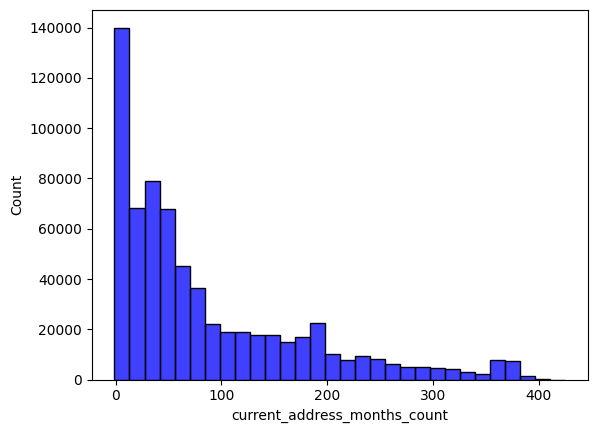

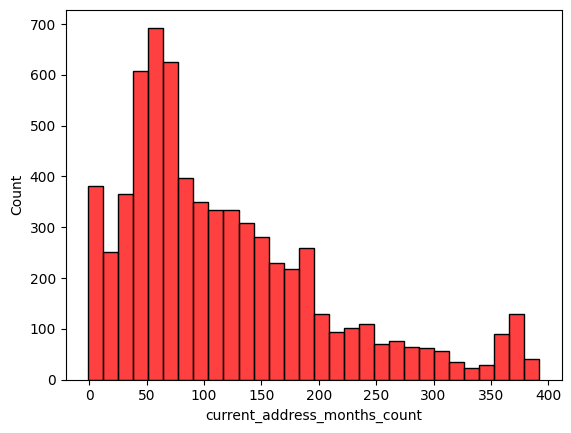

In [143]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['current_address_months_count'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['current_address_months_count'], bins=30, color='red')
plt.show()

In [144]:
top_5 = df_train[df_train['fraud_bool'] == 0]['current_address_months_count'].value_counts().head(5)
print(top_5)

current_address_months_count
7    11438
6    11385
8    11338
5    11094
9    11033
Name: count, dtype: int64


In [145]:
top_5 = df_train[df_train['fraud_bool'] == 1]['current_address_months_count'].value_counts().head(5)
print(top_5)

current_address_months_count
52    66
66    66
47    62
59    61
69    60
Name: count, dtype: int64


In [146]:
#-1 есть, но мало. заменим на НаН
df_train['current_address_months_count'] = df_train['current_address_months_count'].replace({-1: np.nan})

/tmp/ipykernel_1625/1373457970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['current_address_months_count'] = df_train['current_address_months_count'].replace({-1: np.nan})


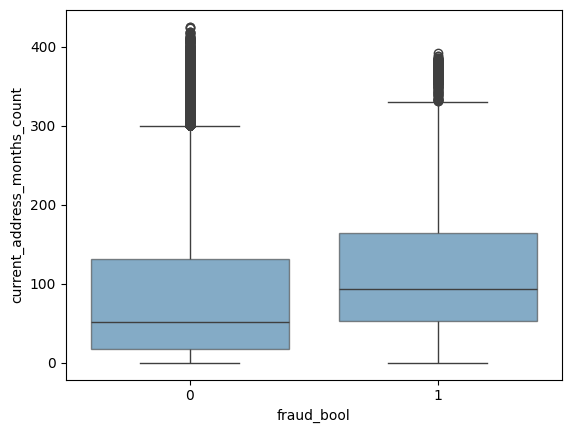

In [147]:
sns.boxplot(data=df_train, x='fraud_bool', y='current_address_months_count', boxprops=dict(alpha=.6))
plt.show()

In [148]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'current_address_months_count')
print(f'Выбросы по current_address_months_count NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'current_address_months_count')
print(f'Выбросы по current_address_months_count fraud: {len(outl)}')

Выбросы по current_address_months_count NOT fraud: 29429
Выбросы по current_address_months_count fraud: 301


In [149]:
df_train[df_train['fraud_bool'] == 0]['current_address_months_count'].info()

df_train[df_train['fraud_bool'] == 1]['current_address_months_count'].info()

<class 'pandas.core.series.Series'>
Index: 668926 entries, 0 to 675665
Series name: current_address_months_count
Non-Null Count   Dtype  
--------------   -----  
666107 non-null  float64
dtypes: float64(1)
memory usage: 10.2 MB
<class 'pandas.core.series.Series'>
Index: 6740 entries, 43 to 675548
Series name: current_address_months_count
Non-Null Count  Dtype  
--------------  -----  
6732 non-null   float64
dtypes: float64(1)
memory usage: 105.3 KB


In [150]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['current_address_months_count'].quantile(0.25)
Q3 = df_train['current_address_months_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['current_address_months_count'] >= lower_bound) & (df_train['current_address_months_count'] <= upper_bound)]['current_address_months_count']

median_value = non_outliers.median()

df_train['current_address_months_count_clean'] = np.where(
    (df_train['current_address_months_count'] < lower_bound) | (df_train['current_address_months_count'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['current_address_months_count']                                                  # Иначе оставить как есть
)

df_test['current_address_months_count_clean'] = np.where(
    (df_test['current_address_months_count'] < lower_bound) | (df_test['current_address_months_count'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['current_address_months_count']                                                  # Иначе оставить как есть
)

df_oot['current_address_months_count_clean'] = np.where(
    (df_oot['current_address_months_count'] < lower_bound) | (df_oot['current_address_months_count'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['current_address_months_count']                                                  # Иначе оставить как есть
)

/tmp/ipykernel_1625/132455616.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['current_address_months_count_clean'] = np.where(
/tmp/ipykernel_1625/132455616.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['current_address_months_count_clean'] = np.where(
/tmp/ipykernel_1625/132455616.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

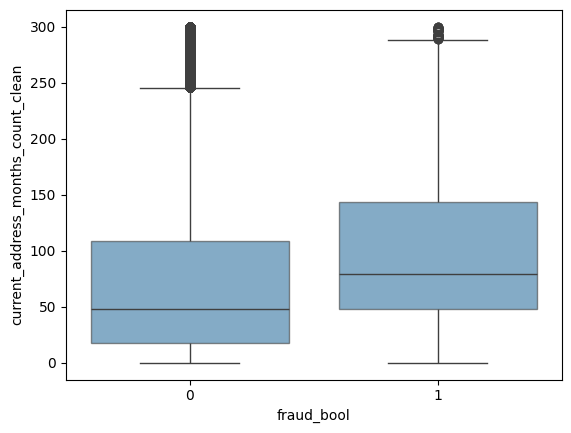

In [151]:
sns.boxplot(data=df_train, x='fraud_bool', y='current_address_months_count_clean', boxprops=dict(alpha=.6))
plt.show()

### days_since_request

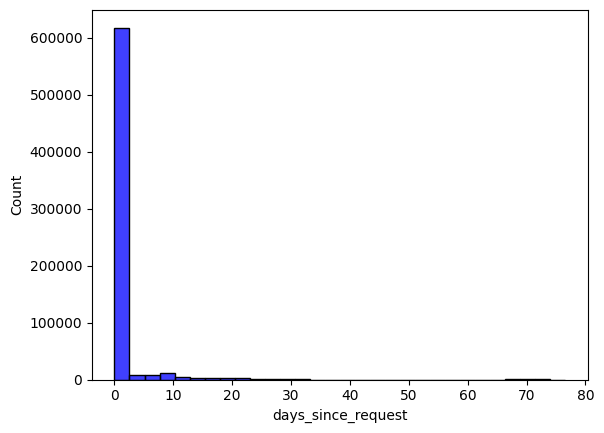

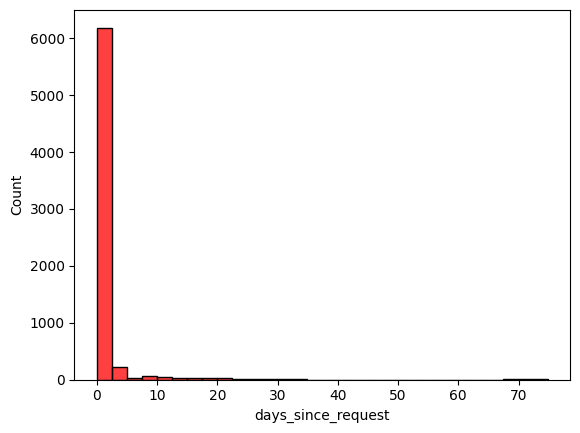

In [152]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['days_since_request'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['days_since_request'], bins=30, color='red')
plt.show()

In [153]:
top_5 = df_train[df_train['fraud_bool'] == 0]['days_since_request'].value_counts().head(5)
print(top_5)

days_since_request
0.022784    3
0.012815    3
0.006703    3
0.016654    3
0.017840    3
Name: count, dtype: int64


In [154]:
#поле "количество дней", значения не круглые - давайте округлим, для анализа дальнейшего
df_train['days_since_request_rounded'] = df_train['days_since_request'].round()

top_5 = df_train[df_train['fraud_bool'] == 0]['days_since_request_rounded'].value_counts().head(5)
print(top_5)

days_since_request_rounded
0.0    597474
1.0     15900
3.0      5954
8.0      4845
9.0      4810
Name: count, dtype: int64


/tmp/ipykernel_1625/3375513808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['days_since_request_rounded'] = df_train['days_since_request'].round()


In [155]:
top_5 = df_train[df_train['fraud_bool'] == 1]['days_since_request_rounded'].value_counts().head(5)
print(top_5)

days_since_request_rounded
0.0    5883
1.0     216
3.0     148
2.0      88
4.0      65
Name: count, dtype: int64


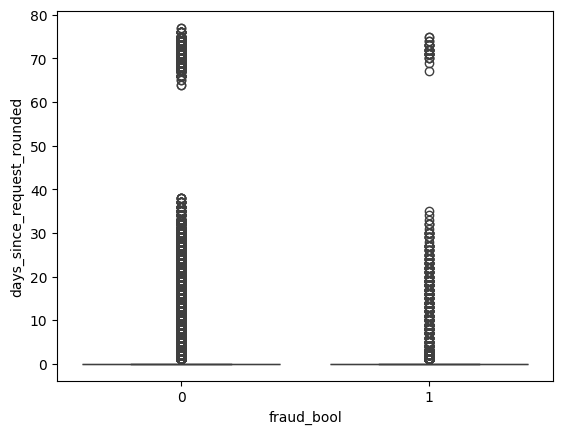

In [156]:
sns.boxplot(data=df_train, x='fraud_bool', y='days_since_request_rounded', boxprops=dict(alpha=.6))
plt.show()

In [157]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'days_since_request_rounded')
print(f'Выбросы по days_since_request_rounded NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'days_since_request_rounded')
print(f'Выбросы по days_since_request_rounded fraud: {len(outl)}')

Выбросы по days_since_request_rounded NOT fraud: 71452
Выбросы по days_since_request_rounded fraud: 857


In [158]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['days_since_request_rounded'].quantile(0.25)
Q3 = df_train['days_since_request_rounded'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['days_since_request_rounded'] >= lower_bound) & (df_train['days_since_request_rounded'] <= upper_bound)]['days_since_request_rounded']

median_value = non_outliers.median()

df_train['days_since_request_rounded_clean'] = np.where(
    (df_train['days_since_request_rounded'] < lower_bound) | (df_train['days_since_request_rounded'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['days_since_request_rounded']                                                  # Иначе оставить как есть
)

df_test['days_since_request_rounded'] = df_test['days_since_request'].round()
df_oot['days_since_request_rounded'] = df_oot['days_since_request'].round()

df_test['days_since_request_rounded_clean'] = np.where(
    (df_test['days_since_request_rounded'] < lower_bound) | (df_test['days_since_request_rounded'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['days_since_request_rounded']                                                  # Иначе оставить как есть
)

df_oot['days_since_request_rounded_clean'] = np.where(
    (df_oot['days_since_request_rounded'] < lower_bound) | (df_oot['days_since_request_rounded'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['days_since_request_rounded']                                                  # Иначе оставить как есть
)

/tmp/ipykernel_1625/1962390736.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['days_since_request_rounded_clean'] = np.where(
/tmp/ipykernel_1625/1962390736.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['days_since_request_rounded'] = df_test['days_since_request'].round()
/tmp/ipykernel_1625/1962390736.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

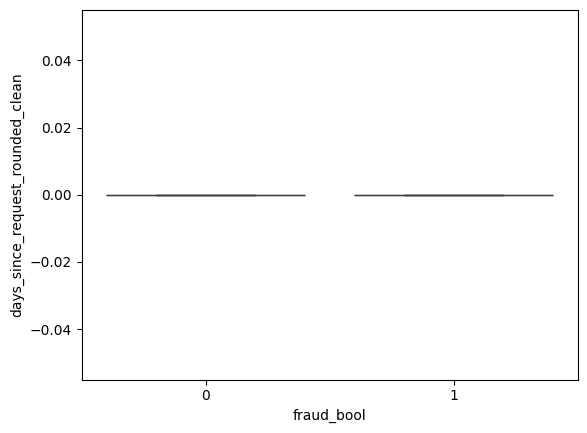

In [159]:
sns.boxplot(data=df_train, x='fraud_bool', y='days_since_request_rounded_clean', boxprops=dict(alpha=.6))
plt.show()

In [160]:
top_5 = df_train[df_train['fraud_bool'] == 0]['days_since_request_rounded_clean'].value_counts().head(5)
print(top_5)

days_since_request_rounded_clean
0.0    668926
Name: count, dtype: int64


In [161]:
top_5 = df_train[df_train['fraud_bool'] == 1]['days_since_request_rounded_clean'].value_counts().head(5)
print(top_5)

days_since_request_rounded_clean
0.0    6740
Name: count, dtype: int64


In [162]:
#дисперсия становится = 0 -> удяляем переменную
df_train = df_train.drop('days_since_request_rounded_clean', axis = 1)
df_train = df_train.drop('days_since_request_rounded', axis = 1)
df_train = df_train.drop('days_since_request', axis = 1)

df_test = df_test.drop('days_since_request_rounded_clean', axis = 1)
df_test = df_test.drop('days_since_request_rounded', axis = 1)
df_test = df_test.drop('days_since_request', axis = 1)

df_oot = df_oot.drop('days_since_request_rounded_clean', axis = 1)
df_oot = df_oot.drop('days_since_request_rounded', axis = 1)
df_oot = df_oot.drop('days_since_request', axis = 1)

### intended_balcon_amount
Мы знаем, что все отрицательное это пустышки

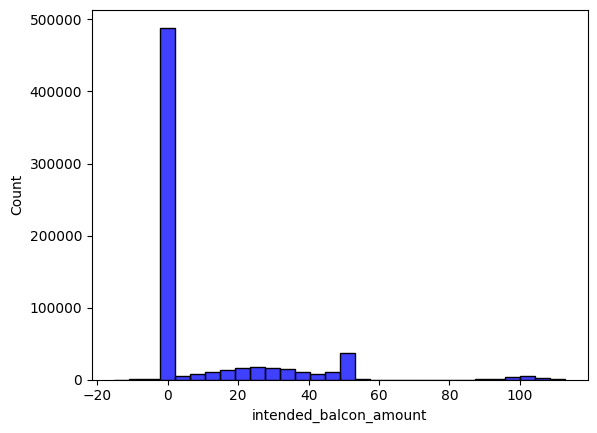

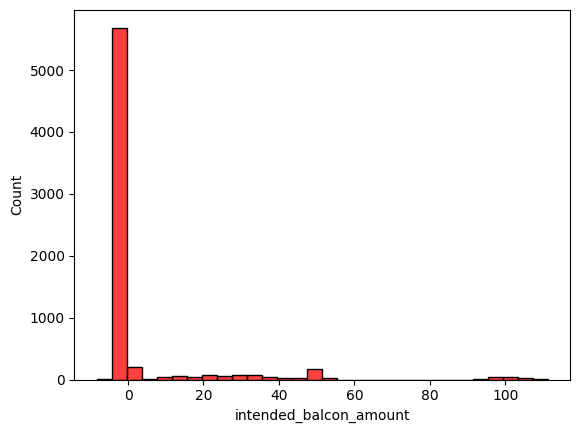

In [163]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['intended_balcon_amount'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['intended_balcon_amount'], bins=30, color='red')
plt.show()

In [164]:
(df_train[df_train['fraud_bool'] == 0]['intended_balcon_amount'] < 0).sum()

np.int64(487888)

In [165]:
df_train['intended_balcon_amount'] = df_train['intended_balcon_amount'].where(df_train['intended_balcon_amount'] >= 0, np.nan)

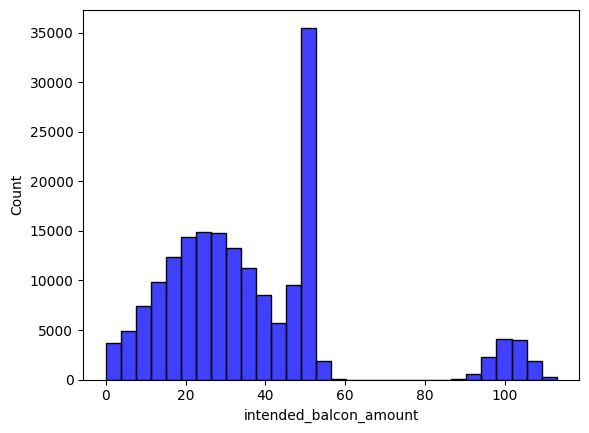

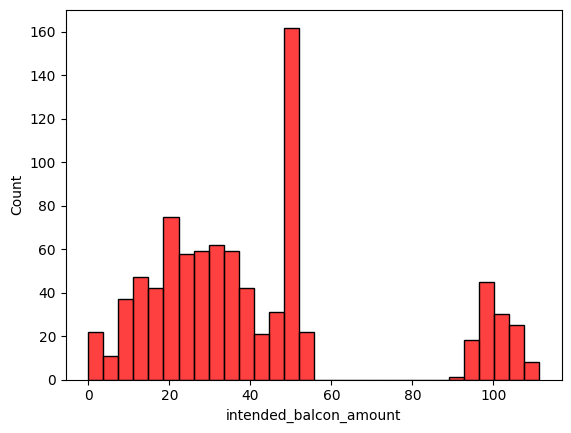

In [166]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['intended_balcon_amount'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['intended_balcon_amount'], bins=30, color='red')
plt.show()

In [167]:
#отчетливо видим 2 горба - бимодальное распределение. Поэтому тут выбросы пока искать не будем. Оба горба достаточно гладкие

### zip_count_4w

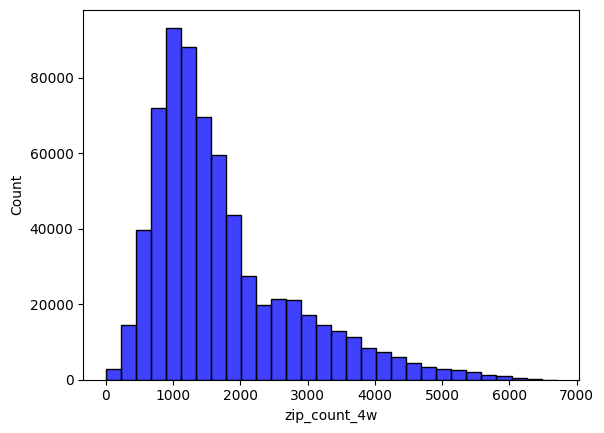

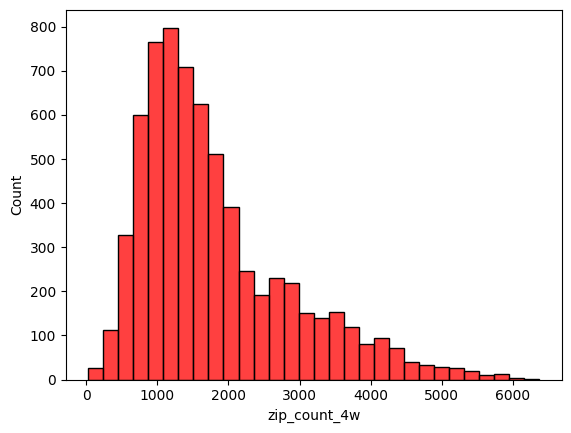

In [168]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['zip_count_4w'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['zip_count_4w'], bins=30, color='red')
plt.show()

In [169]:
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'zip_count_4w')
print(f'Выбросы по zip_count_4w NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'zip_count_4w')
print(f'Выбросы по zip_count_4w fraud: {len(outl)}')

Выбросы по zip_count_4w NOT fraud: 36499
Выбросы по zip_count_4w fraud: 278


In [170]:
36499/675666

0.05401929355628372

In [171]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['zip_count_4w'].quantile(0.25)
Q3 = df_train['zip_count_4w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['zip_count_4w'] >= lower_bound) & (df_train['zip_count_4w'] <= upper_bound)]['zip_count_4w']

median_value = non_outliers.median()

df_train['zip_count_4w_clean'] = np.where(
    (df_train['zip_count_4w'] < lower_bound) | (df_train['zip_count_4w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['zip_count_4w']                                                  # Иначе оставить как есть
)

df_test['zip_count_4w_clean'] = np.where(
    (df_test['zip_count_4w'] < lower_bound) | (df_test['zip_count_4w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['zip_count_4w']                                                  # Иначе оставить как есть
)

df_oot['zip_count_4w_clean'] = np.where(
    (df_oot['zip_count_4w'] < lower_bound) | (df_oot['zip_count_4w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['zip_count_4w']                                                  # Иначе оставить как есть
)

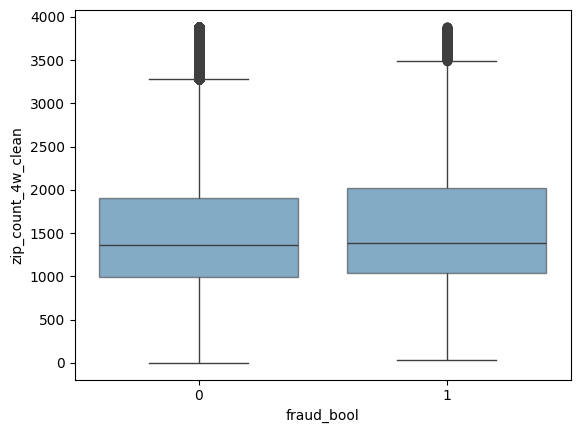

In [172]:
sns.boxplot(data=df_train, x='fraud_bool', y='zip_count_4w_clean', boxprops=dict(alpha=.6))
plt.show()

### velocity_6h
Velocity of total applications made in last 6 hours i.e., average number of applications per hour in the last 6 hours. Ranges between [−211, 24763].

по смысле не может быть отрицательным. Мы явно этого не знаем, но предположим, что также отрицательные значения - пустышки

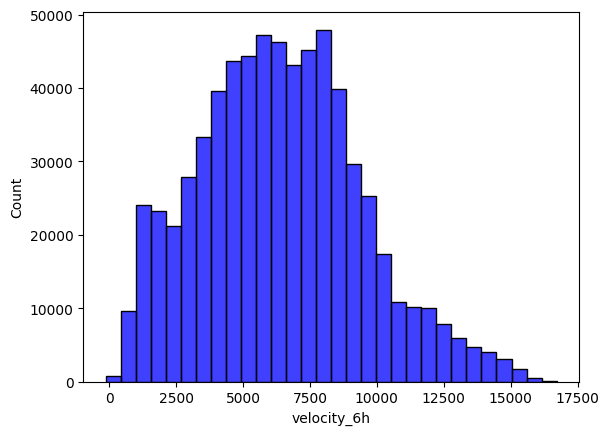

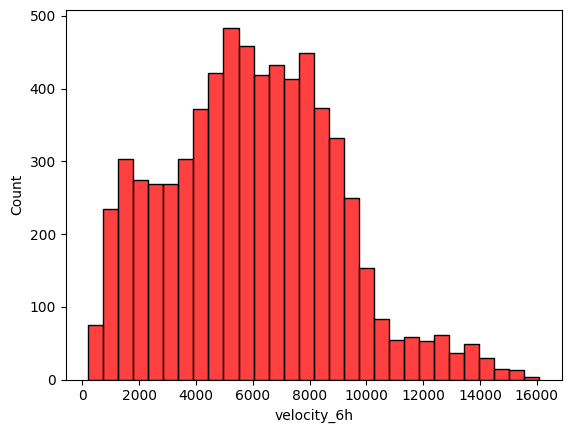

In [173]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['velocity_6h'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['velocity_6h'], bins=30, color='red')
plt.show()

In [174]:
(df_train[df_train['fraud_bool'] == 0]['velocity_6h'] < 0).sum()

np.int64(9)

In [175]:
(df_train[df_train['fraud_bool'] == 1]['velocity_6h'] < 0).sum()

np.int64(0)

In [176]:
df_train['velocity_6h'] = df_train['velocity_6h'].where(
    df_train['velocity_6h'] >= 0, np.nan
)

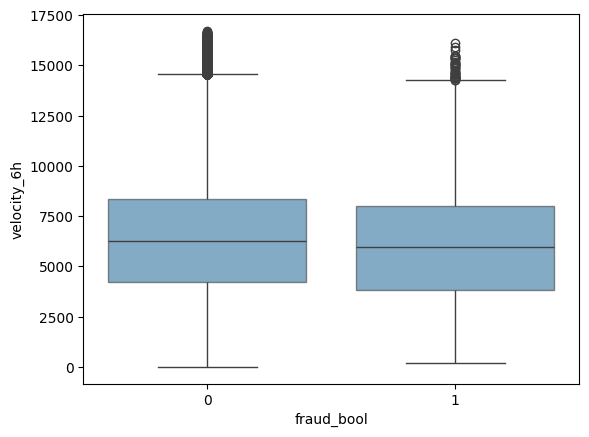

In [177]:
sns.boxplot(data=df_train, x='fraud_bool', y='velocity_6h', boxprops=dict(alpha=.6))
plt.show()

In [178]:
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'velocity_6h')
print(f'Выбросы по velocity_6h NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'velocity_6h')
print(f'Выбросы по velocity_6h fraud: {len(outl)}')

Выбросы по velocity_6h NOT fraud: 4831
Выбросы по velocity_6h fraud: 43


In [179]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['velocity_6h'].quantile(0.25)
Q3 = df_train['velocity_6h'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['velocity_6h'] >= lower_bound) & (df_train['velocity_6h'] <= upper_bound)]['velocity_6h']

median_value = non_outliers.median()

df_train['velocity_6h_clean'] = np.where(
    (df_train['velocity_6h'] < lower_bound) | (df_train['velocity_6h'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['velocity_6h']                                                  # Иначе оставить как есть
)

df_test['velocity_6h_clean'] = np.where(
    (df_test['velocity_6h'] < lower_bound) | (df_test['velocity_6h'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['velocity_6h']                                                  # Иначе оставить как есть
)

df_oot['velocity_6h_clean'] = np.where(
    (df_oot['velocity_6h'] < lower_bound) | (df_oot['velocity_6h'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['velocity_6h']                                                  # Иначе оставить как есть
)

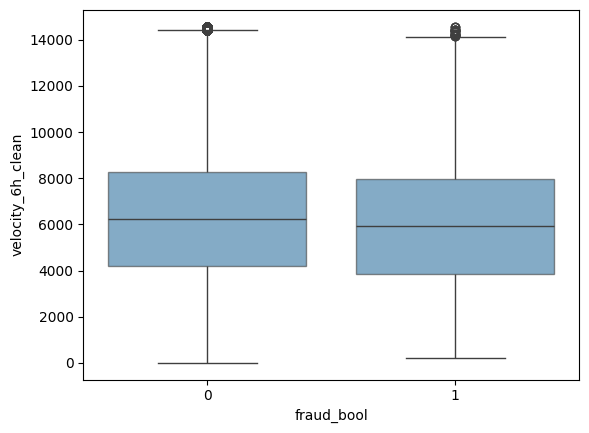

In [180]:
sns.boxplot(data=df_train, x='fraud_bool', y='velocity_6h_clean', boxprops=dict(alpha=.6))
plt.show()

### velocity_24h

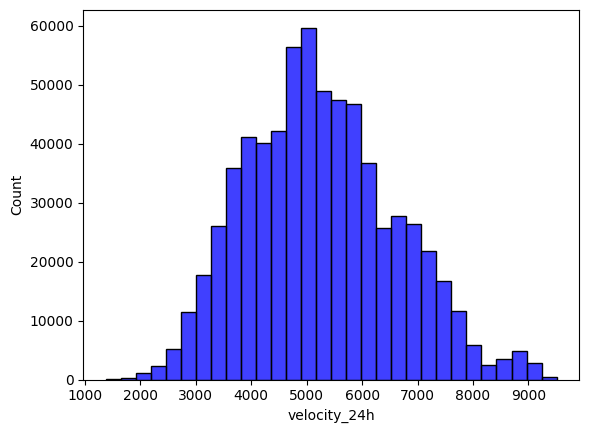

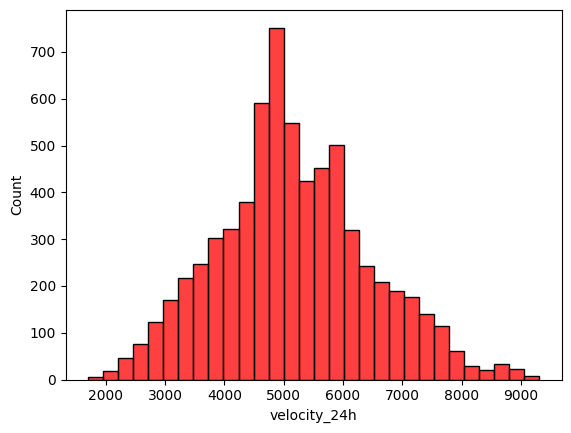

In [181]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['velocity_24h'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['velocity_24h'], bins=30, color='red')
plt.show()

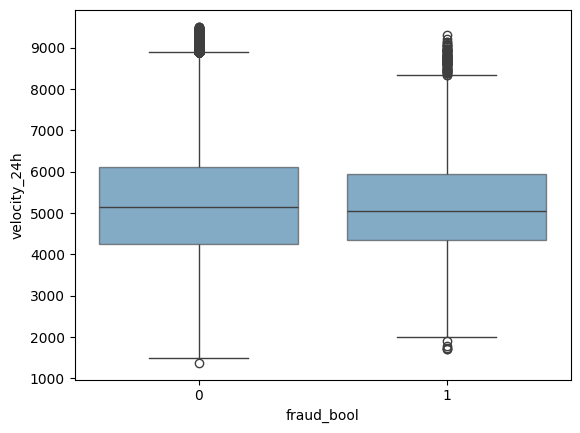

In [182]:
sns.boxplot(data=df_train, x='fraud_bool', y='velocity_24h', boxprops=dict(alpha=.6))
plt.show()

In [183]:
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'velocity_24h')
print(f'Выбросы по velocity_6h NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'velocity_24h')
print(f'Выбросы по velocity_6h fraud: {len(outl)}')

Выбросы по velocity_6h NOT fraud: 4573
Выбросы по velocity_6h fraud: 84


In [184]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['velocity_24h'].quantile(0.25)
Q3 = df_train['velocity_24h'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['velocity_24h'] >= lower_bound) & (df_train['velocity_24h'] <= upper_bound)]['velocity_24h']

median_value = non_outliers.median()

df_train['velocity_24h_clean'] = np.where(
    (df_train['velocity_24h'] < lower_bound) | (df_train['velocity_24h'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['velocity_24h']                                                  # Иначе оставить как есть
)

df_test['velocity_24h_clean'] = np.where(
    (df_test['velocity_24h'] < lower_bound) | (df_test['velocity_24h'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['velocity_24h']                                                  # Иначе оставить как есть
)

df_oot['velocity_24h_clean'] = np.where(
    (df_oot['velocity_24h'] < lower_bound) | (df_oot['velocity_24h'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['velocity_24h']                                                  # Иначе оставить как есть
)

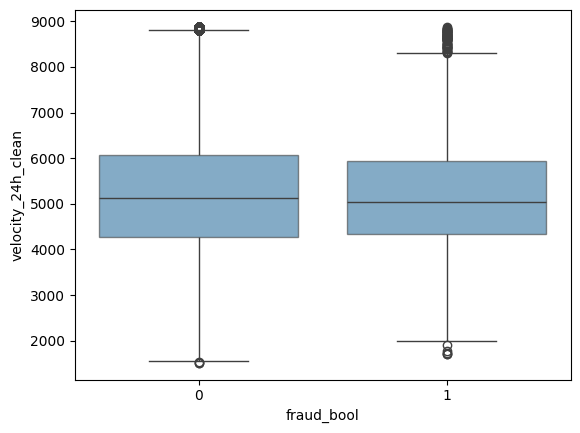

In [185]:
sns.boxplot(data=df_train, x='fraud_bool', y='velocity_24h_clean', boxprops=dict(alpha=.6))
plt.show()

### bank_branch_count_8w

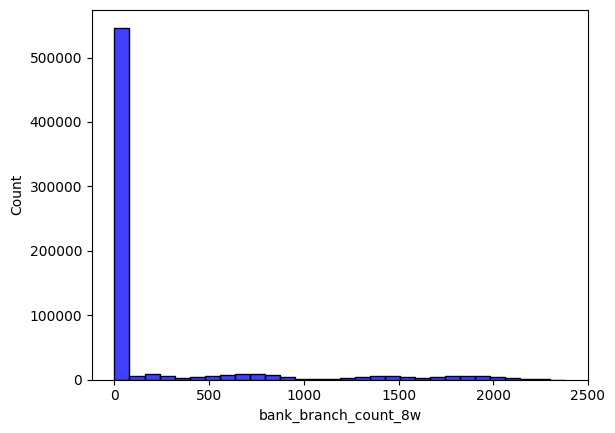

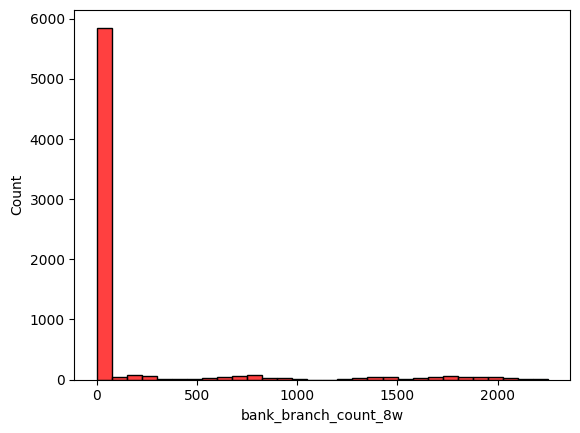

In [186]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['bank_branch_count_8w'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['bank_branch_count_8w'], bins=30, color='red')
plt.show()

In [187]:
top_5 = df_train[df_train['fraud_bool'] == 0]['bank_branch_count_8w'].value_counts().head(5)
print(top_5)

bank_branch_count_8w
1     99263
0     97014
2     38593
11    19522
10    19162
Name: count, dtype: int64


In [188]:
top_5 = df_train[df_train['fraud_bool'] == 1]['bank_branch_count_8w'].value_counts().head(5)
print(top_5)

bank_branch_count_8w
0     1590
1     1468
2      457
13     171
10     166
Name: count, dtype: int64


In [189]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'bank_branch_count_8w')
print(f'Выбросы по bank_branch_count_8w NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'bank_branch_count_8w')
print(f'Выбросы по bank_branch_count_8w fraud: {len(outl)}')

Выбросы по bank_branch_count_8w NOT fraud: 122705
Выбросы по bank_branch_count_8w fraud: 1049


In [190]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['bank_branch_count_8w'].quantile(0.25)
Q3 = df_train['bank_branch_count_8w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['bank_branch_count_8w'] >= lower_bound) & (df_train['bank_branch_count_8w'] <= upper_bound)]['bank_branch_count_8w']

median_value = non_outliers.median()

df_train['bank_branch_count_8w_clean'] = np.where(
    (df_train['bank_branch_count_8w'] < lower_bound) | (df_train['bank_branch_count_8w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['bank_branch_count_8w']                                                  # Иначе оставить как есть
)

df_test['bank_branch_count_8w_clean'] = np.where(
    (df_test['bank_branch_count_8w'] < lower_bound) | (df_test['bank_branch_count_8w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['bank_branch_count_8w']                                                  # Иначе оставить как есть
)

df_oot['bank_branch_count_8w_clean'] = np.where(
    (df_oot['bank_branch_count_8w'] < lower_bound) | (df_oot['bank_branch_count_8w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['bank_branch_count_8w']                                                  # Иначе оставить как есть
)

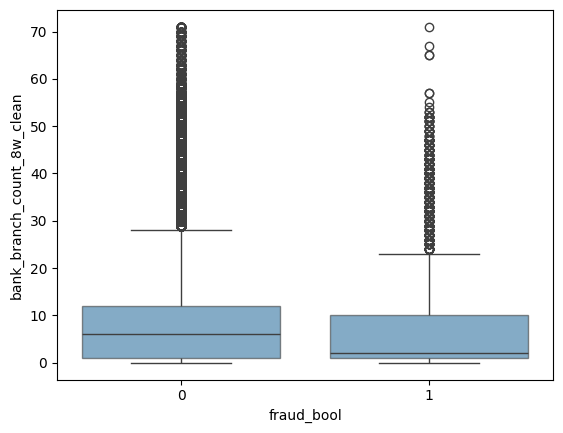

In [191]:
sns.boxplot(data=df_train, x='fraud_bool', y='bank_branch_count_8w_clean', boxprops=dict(alpha=.6))
plt.show()

In [192]:
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'bank_branch_count_8w_clean')
print(f'Выбросы по bank_branch_count_8w NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'bank_branch_count_8w_clean')
print(f'Выбросы по bank_branch_count_8w fraud: {len(outl)}')

Выбросы по bank_branch_count_8w NOT fraud: 47174
Выбросы по bank_branch_count_8w fraud: 443


### date_of_birth_distinct_emails_4w

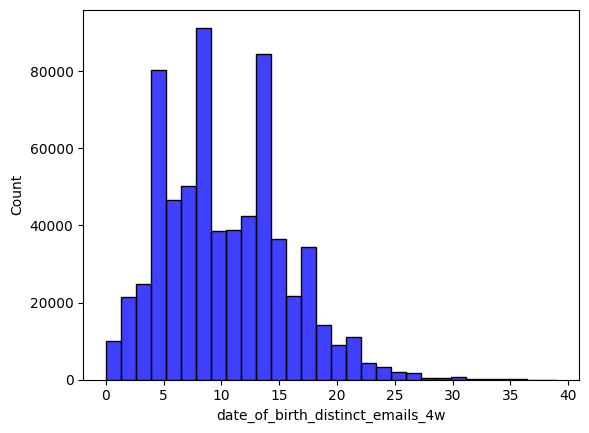

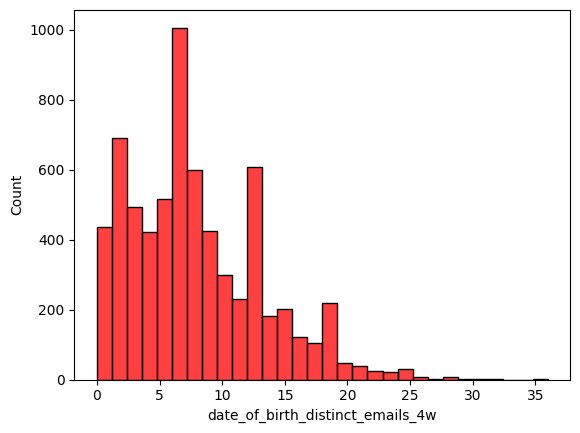

In [193]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['date_of_birth_distinct_emails_4w'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['date_of_birth_distinct_emails_4w'], bins=30, color='red')
plt.show()

In [194]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'date_of_birth_distinct_emails_4w')
print(f'Выбросы по date_of_birth_distinct_emails_4w NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'date_of_birth_distinct_emails_4w')
print(f'Выбросы по date_of_birth_distinct_emails_4w fraud: {len(outl)}')

Выбросы по date_of_birth_distinct_emails_4w NOT fraud: 2582
Выбросы по date_of_birth_distinct_emails_4w fraud: 101


In [195]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['date_of_birth_distinct_emails_4w'].quantile(0.25)
Q3 = df_train['date_of_birth_distinct_emails_4w'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['date_of_birth_distinct_emails_4w'] >= lower_bound) & (df_train['date_of_birth_distinct_emails_4w'] <= upper_bound)]['date_of_birth_distinct_emails_4w']

median_value = non_outliers.median()

df_train['date_of_birth_distinct_emails_4w_clean'] = np.where(
    (df_train['date_of_birth_distinct_emails_4w'] < lower_bound) | (df_train['date_of_birth_distinct_emails_4w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['date_of_birth_distinct_emails_4w']                                                  # Иначе оставить как есть
)

df_test['date_of_birth_distinct_emails_4w_clean'] = np.where(
    (df_test['date_of_birth_distinct_emails_4w'] < lower_bound) | (df_test['date_of_birth_distinct_emails_4w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['date_of_birth_distinct_emails_4w']                                                  # Иначе оставить как есть
)

df_oot['date_of_birth_distinct_emails_4w_clean'] = np.where(
    (df_oot['date_of_birth_distinct_emails_4w'] < lower_bound) | (df_oot['date_of_birth_distinct_emails_4w'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['date_of_birth_distinct_emails_4w']                                                  # Иначе оставить как есть
)

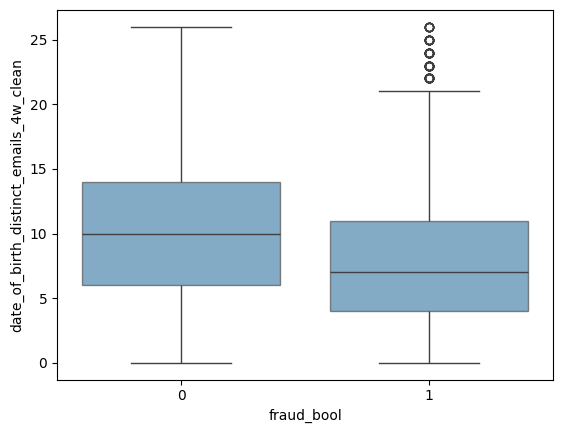

In [196]:
sns.boxplot(data=df_train, x='fraud_bool', y='date_of_birth_distinct_emails_4w_clean', boxprops=dict(alpha=.6))
plt.show()

### credit_risk_score
мы не знаем, какая шкала применена -> не понимаем, нормальны ли отрицательные значения.
Т к их довольно много разнообразных - предположим, что они нормальны

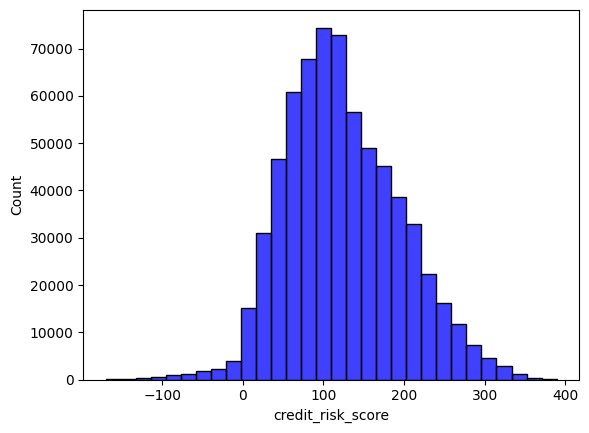

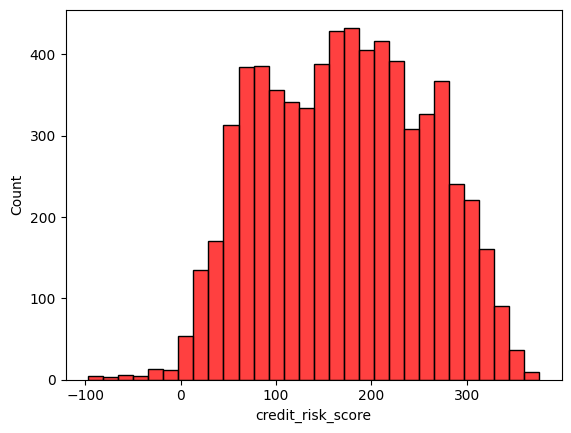

In [197]:
sns.histplot(df_train[df_train['fraud_bool'] == 0]['credit_risk_score'], bins=30, color='blue')
plt.show()

sns.histplot(df_train[df_train['fraud_bool'] == 1]['credit_risk_score'], bins=30, color='red')
plt.show()

In [198]:
#теперь мы видим много выбросов, давайте их посчитаем
outl = find_outliers(df_train[df_train['fraud_bool'] == 0], 'credit_risk_score')
print(f'Выбросы по credit_risk_score NOT fraud: {len(outl)}')

outl = find_outliers(df_train[df_train['fraud_bool'] == 1], 'credit_risk_score')
print(f'Выбросы по credit_risk_score fraud: {len(outl)}')

Выбросы по credit_risk_score NOT fraud: 5236
Выбросы по credit_risk_score fraud: 0


In [199]:
#так как подход поиска прототипов чувствителен к выбросам, с ними необходимо работать
#заменим их на медианное значение соответствующее для каждой группы (фрод-не фрод), чтобы затем это меньше повлияло на поиск прототипов

Q1 = df_train['credit_risk_score'].quantile(0.25)
Q3 = df_train['credit_risk_score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outliers = df_train[(df_train['credit_risk_score'] >= lower_bound) & (df_train['credit_risk_score'] <= upper_bound)]['credit_risk_score']

median_value = non_outliers.median()

df_train['credit_risk_score_clean'] = np.where(
    (df_train['credit_risk_score'] < lower_bound) | (df_train['credit_risk_score'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_train['credit_risk_score']                                                  # Иначе оставить как есть
)

df_test['credit_risk_score_clean'] = np.where(
    (df_test['credit_risk_score'] < lower_bound) | (df_test['credit_risk_score'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_test['credit_risk_score']                                                  # Иначе оставить как есть
)

df_oot['credit_risk_score_clean'] = np.where(
    (df_oot['credit_risk_score'] < lower_bound) | (df_oot['credit_risk_score'] > upper_bound),  # Условие
    median_value,                                                 # Замена на медиану
    df_oot['credit_risk_score']                                                  # Иначе оставить как есть
)

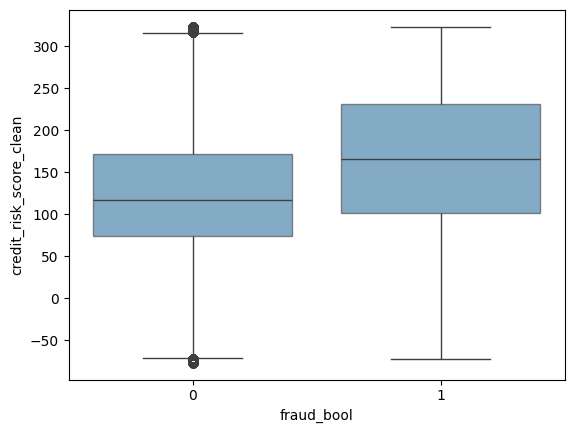

In [200]:
sns.boxplot(data=df_train, x='fraud_bool', y='credit_risk_score_clean', boxprops=dict(alpha=.6))
plt.show()

## Анализ и подбор переменных

### Шаг 1 экспертный отбор

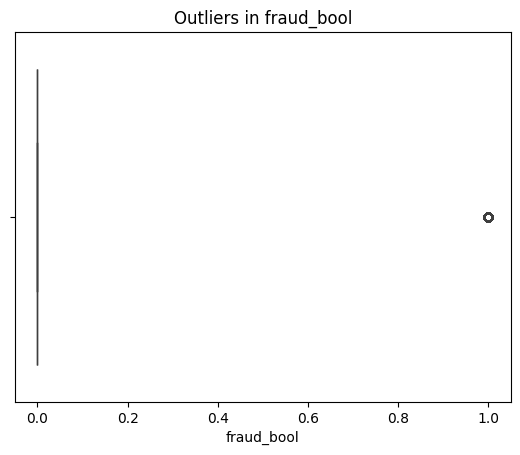

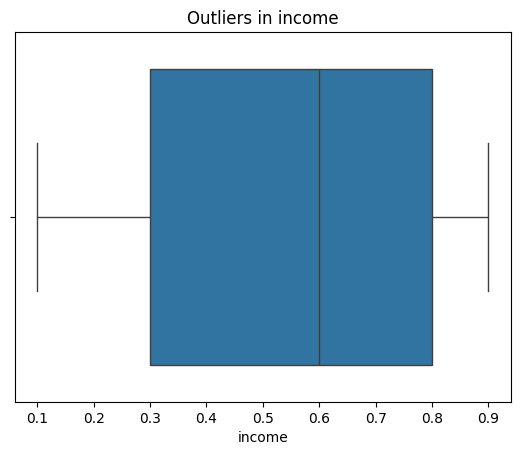

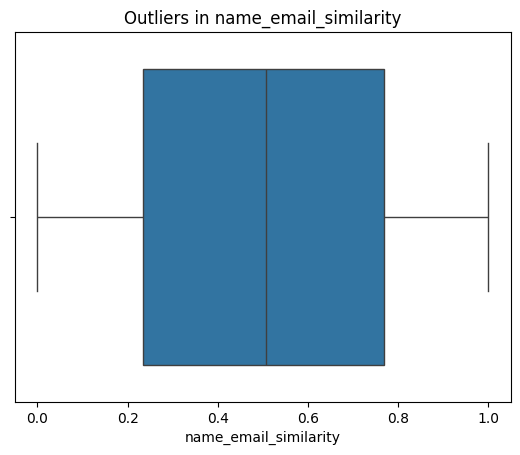

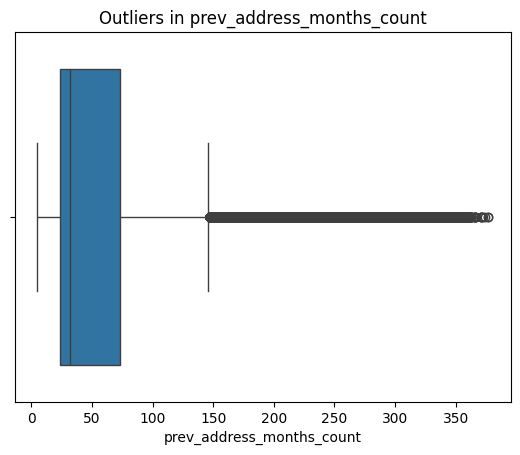

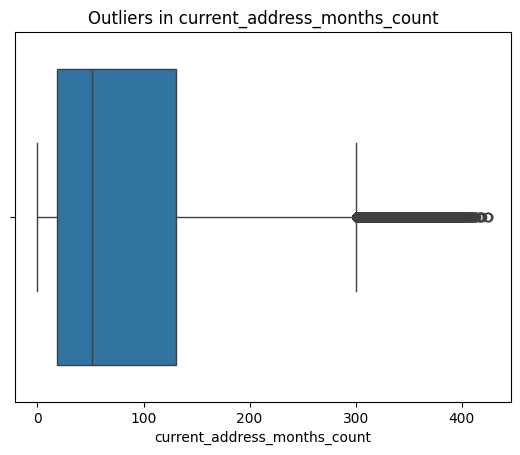

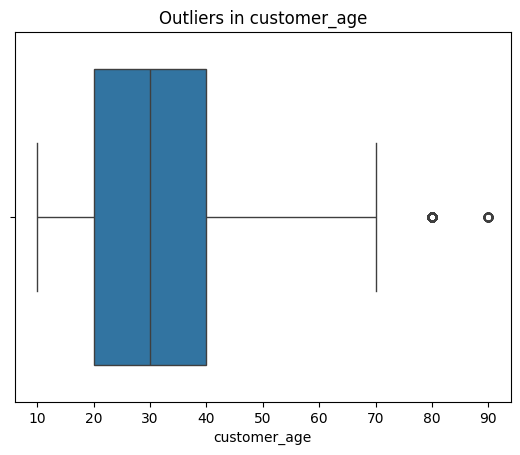

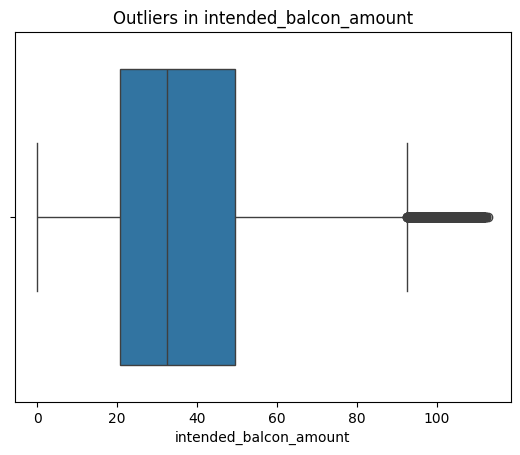

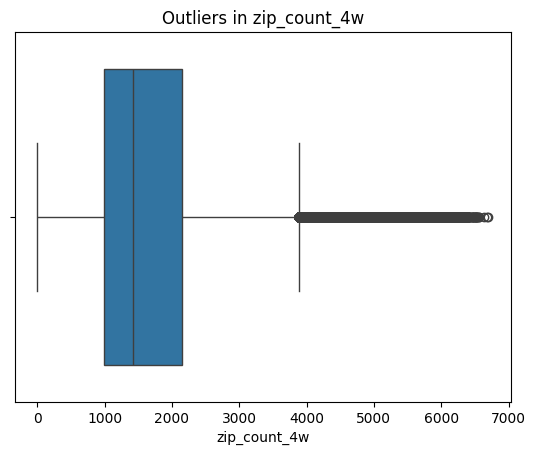

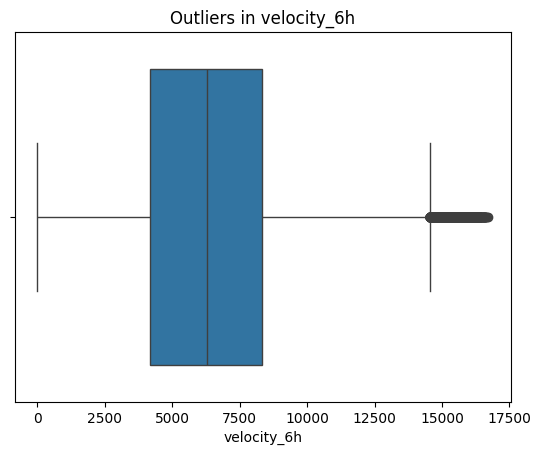

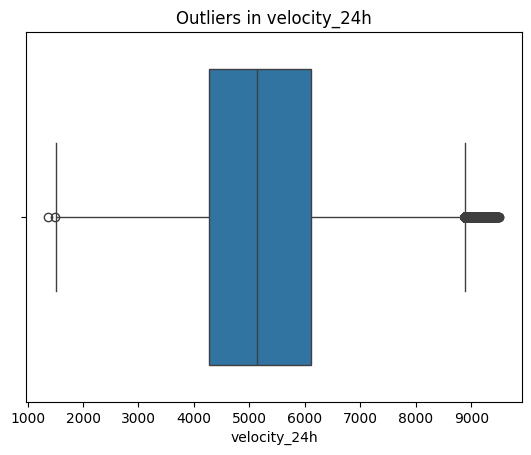

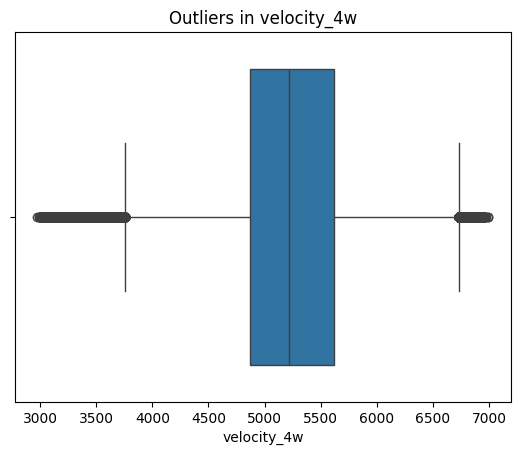

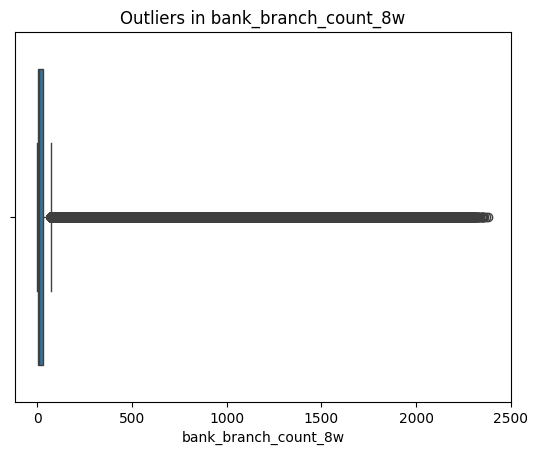

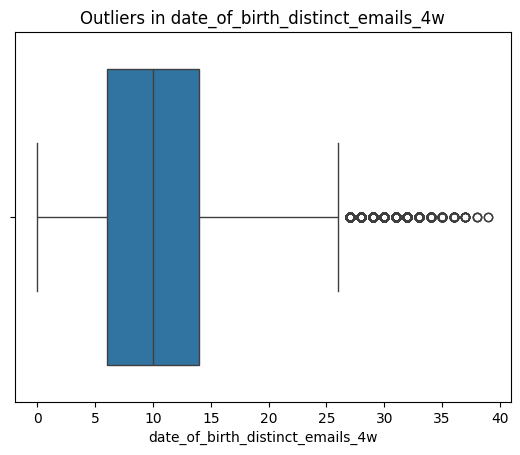

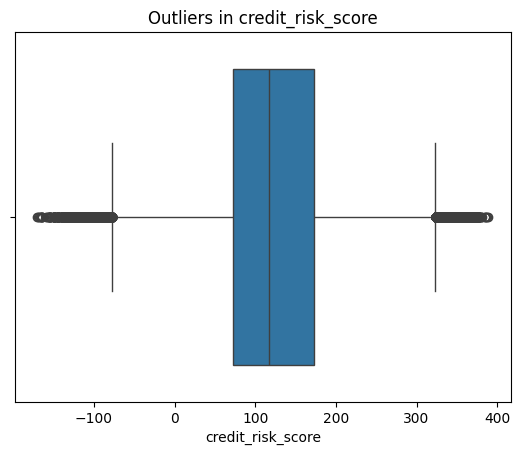

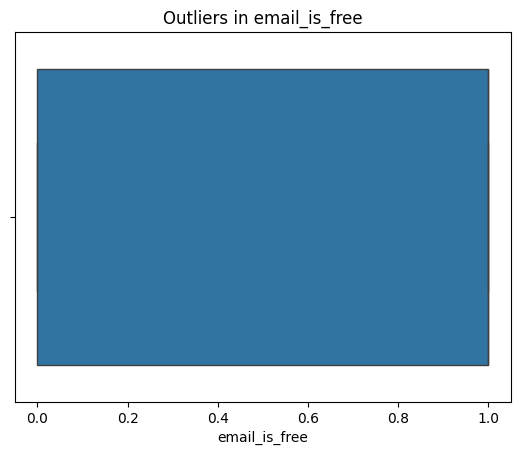

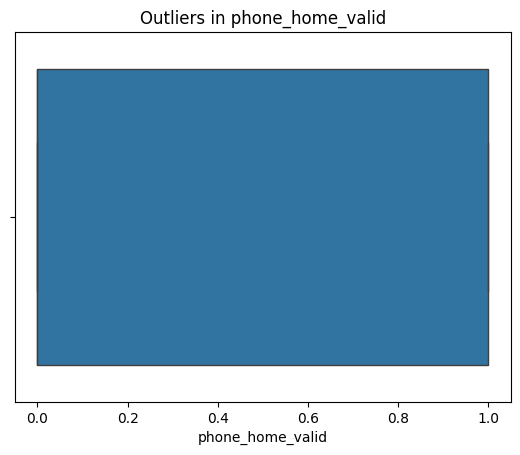

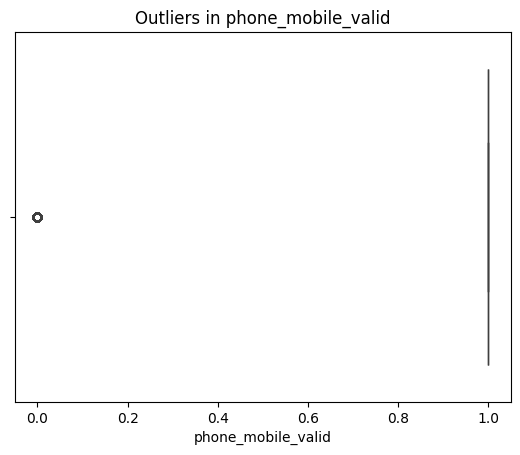

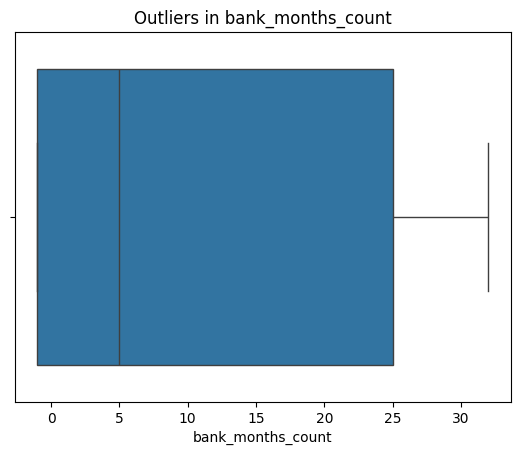

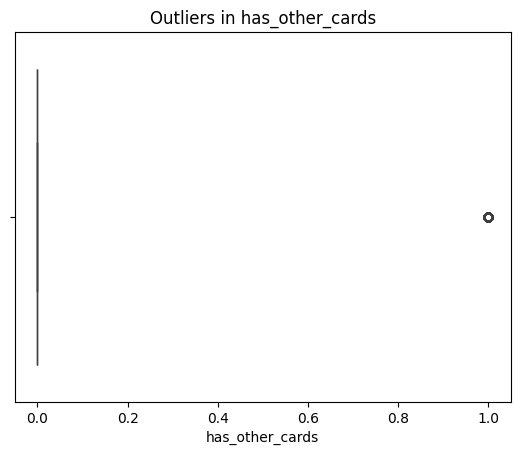

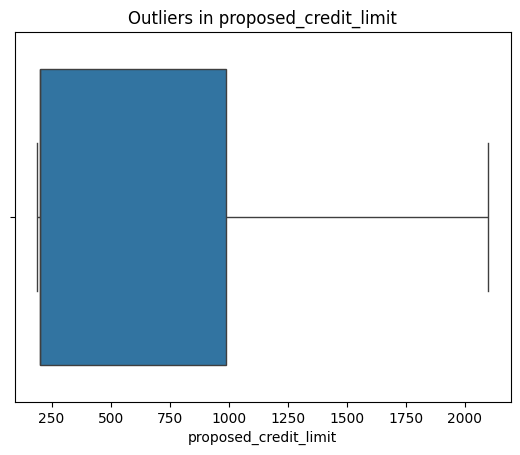

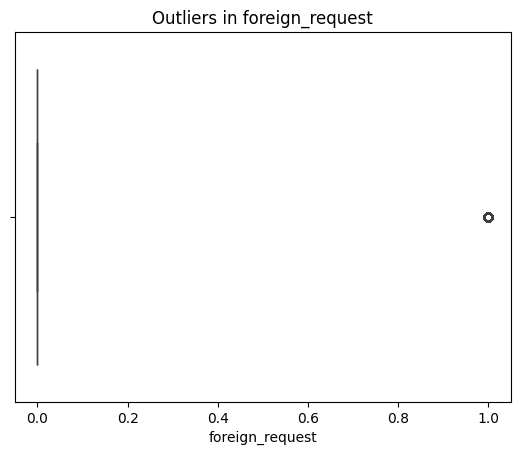

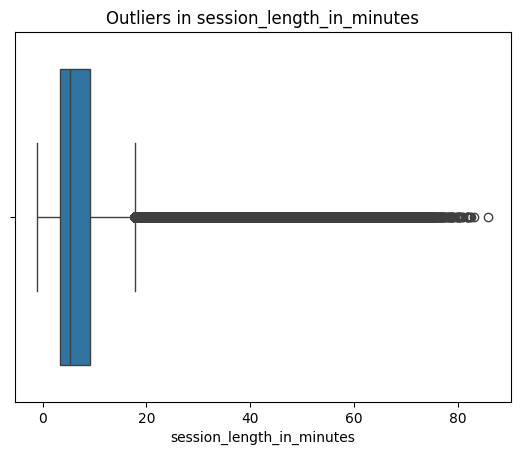

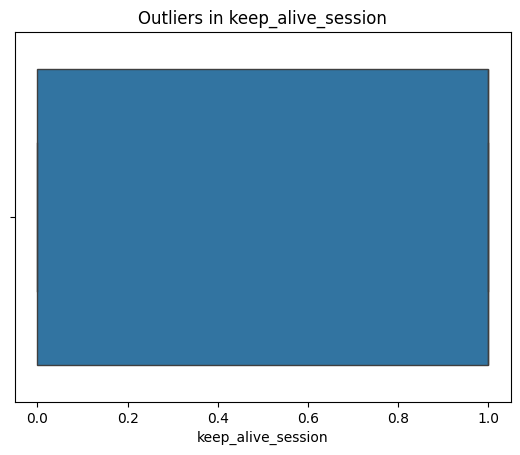

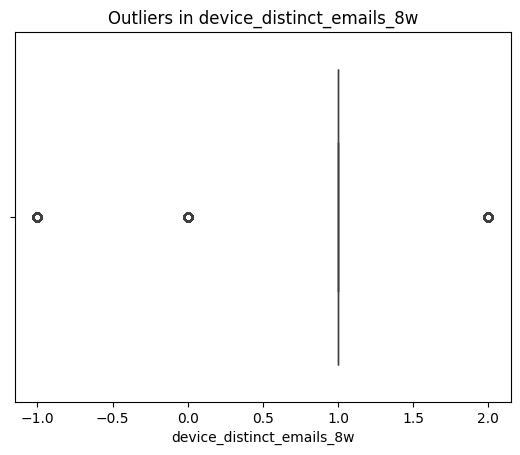

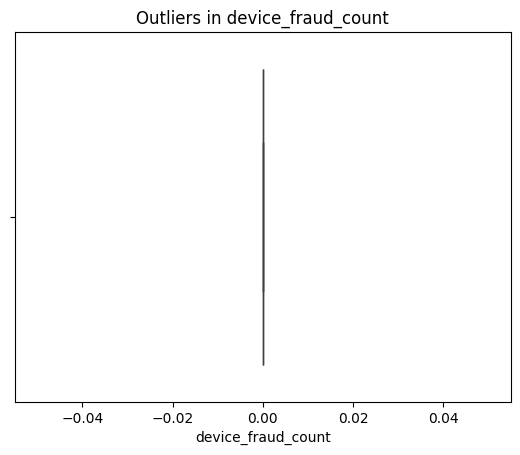

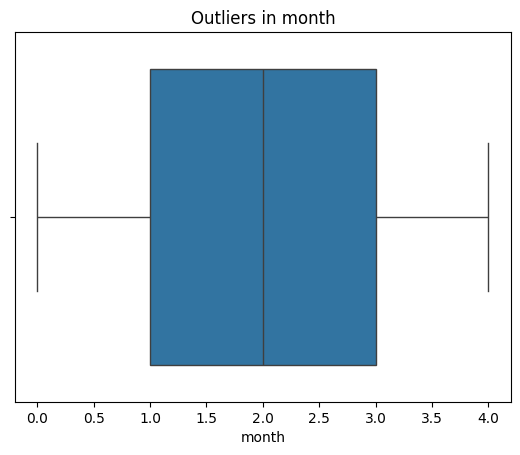

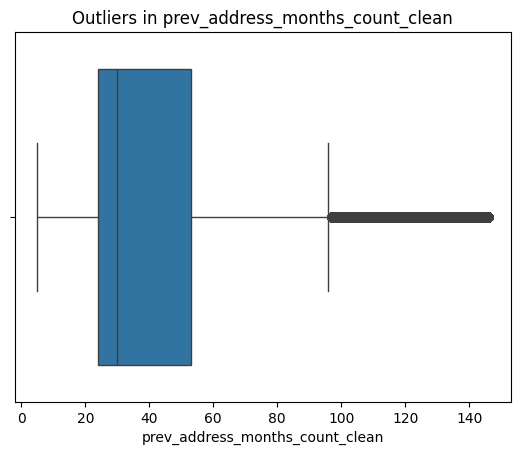

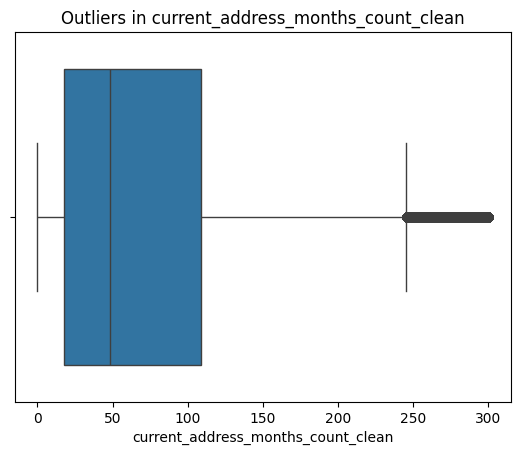

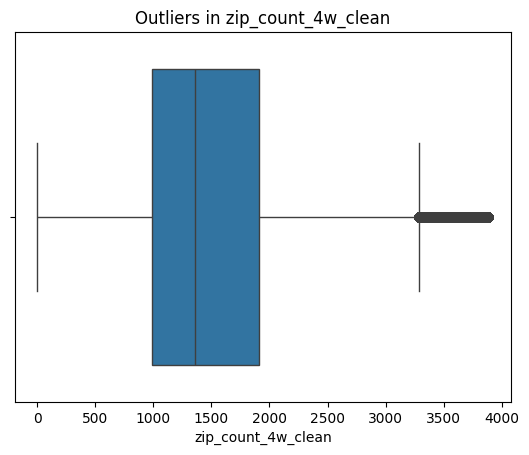

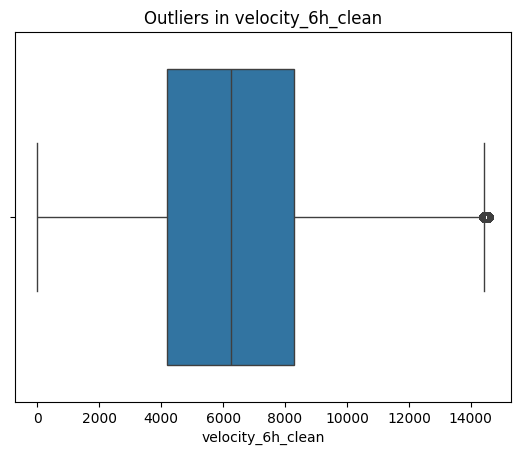

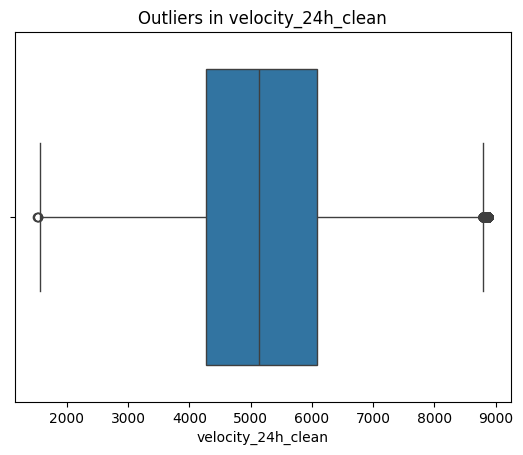

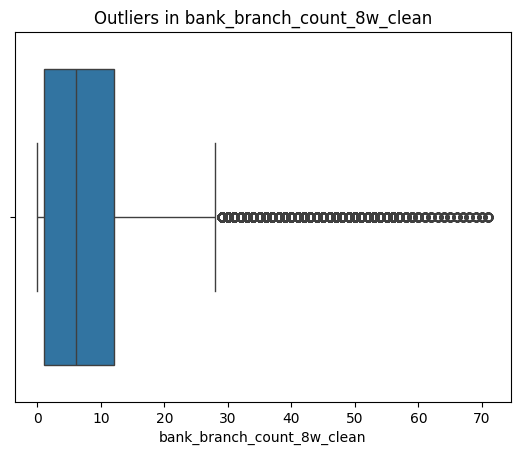

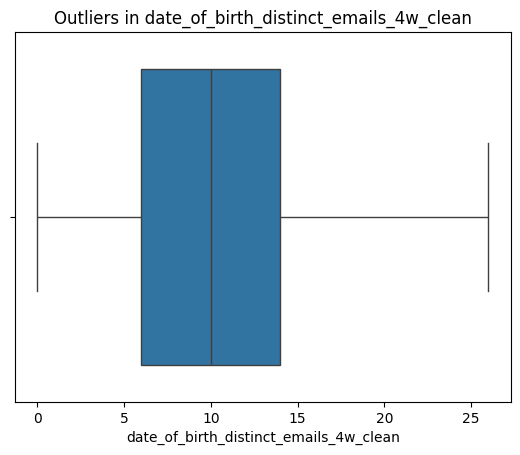

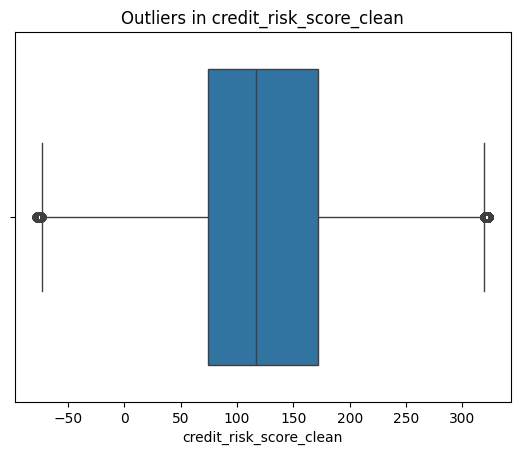

In [201]:
#экспертный отбор признаков.
#Уберем признаки с большим числом не заполненных значений и нестабильным распределением
#для анализа используем трайн-тест часть

#посмотрим числовые переменные
#посмотрим на графики, предположим, где могут быть незаполеннные и нестабильные переменные
num_columns = list(df_train.select_dtypes(include=['float64', 'int64']).columns)

for col in num_columns:
    sns.boxplot(x=df_train[col])
    plt.title(f"Outliers in {col}")
    plt.show()

#претенденты на удаление:
# prev_address_months_count - Number of months in previous registered address of the applicant, i.e. the applicant’s previous residence, if applicable.
#   Ranges between [−1, 380] months (-1 is a missing value) По всей видиммости слишком много незаполненных
# days_since_request - Number of days passed since application was done. Ranges between [0, 78] days. Очень много выбросов, требует как минимум очистки
# intended_balcon_amount - Initial transferred amount for application. Ranges between [−1, 108]
#   присутствуют отрицательные значения, даже вне рейнджа заявленного составителем датасета
# zip_count_4w - Number of applications within same zip code in last 4 weeks. Ranges between [1, 5767] возможно 2 горба, и нет так много выбросов
# bank_branch_count_8w - Number of total applications in the selected bank branch in last 8 weeks. Ranges between [0, 2521]
#   много выбросов, мало нормальных значений. но вообще непонятно, может они как раз и есть подозрительные - несбалансированные данные ж
# device_distinct_emails_8w - есть отроицательные значения, которых быть не должно
# device_fraud_count - все нули, не имеет смысла
#
#
# Глобальный вопрос - стоит ли выбрасывать выбросы? т к выборка не сбалансированная, возмонжо наши выбросы, это и есть показатели фрода
####

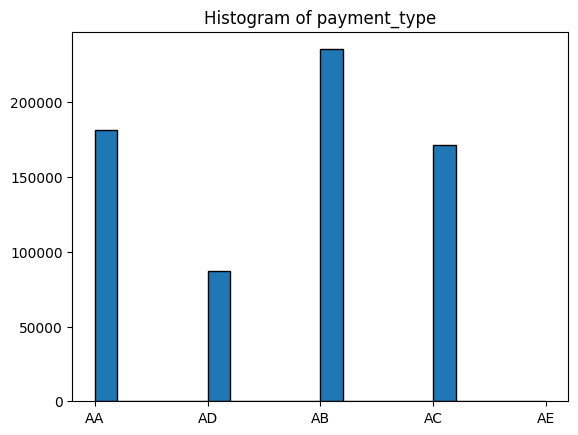

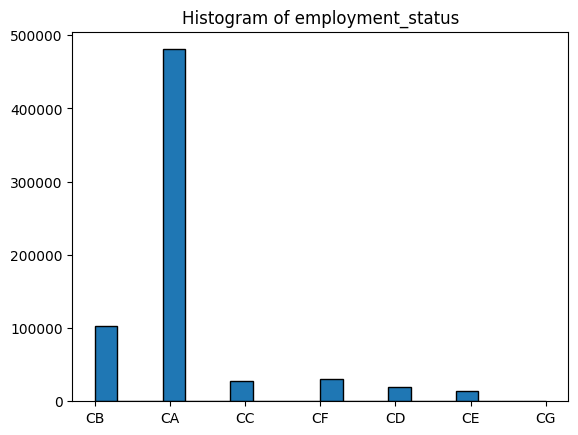

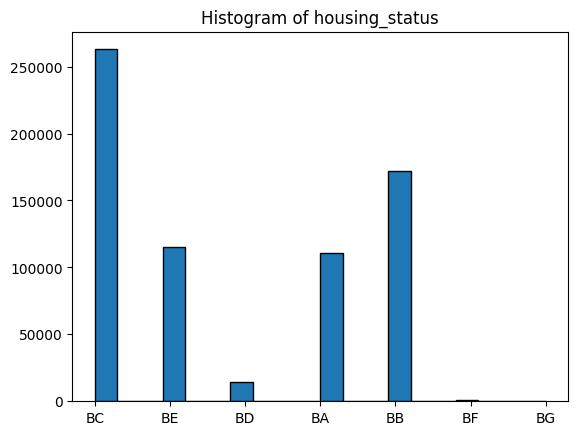

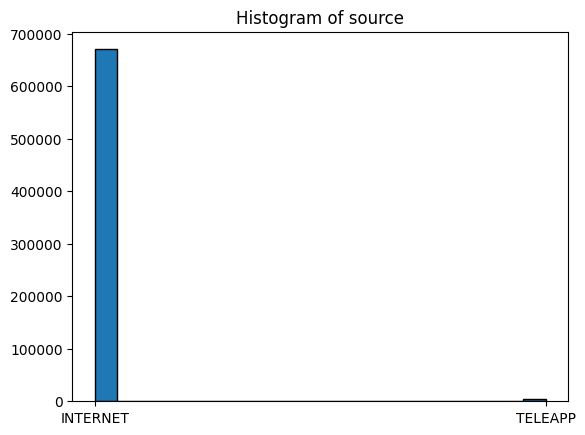

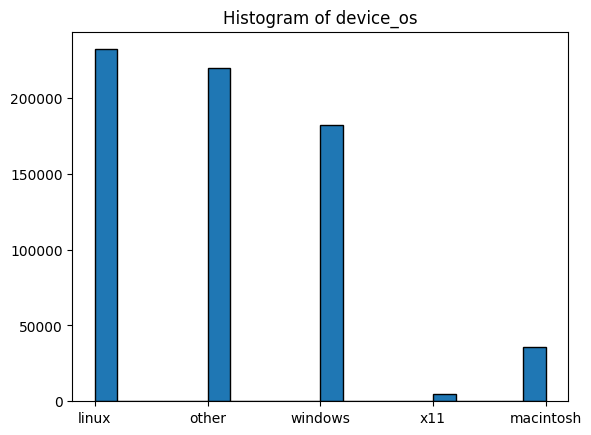

In [202]:
#Посмотрим категориальные переменные на гистограммах

num_columns = list(df_train.select_dtypes(include=['object']).columns)

for col in num_columns:
    plt.hist(df_train[col], bins = 20, edgecolor = 'k')
    plt.title(f"Histogram of {col}")
    plt.show()

# претенденты на доп анализ:
# payment_type - очень мало категории AE
# source - будто все internet
# device_os - очень мало значений в категории x11
####

In [203]:
df_train[['device_fraud_count']].describe() # точно выбрасываем, совсем не меняется

,device_fraud_count
count,675666.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [204]:
df_train[['source']].describe()

,source
count,675666
unique,2
top,INTERNET
freq,670596


In [205]:
df_train = df_train.drop('device_fraud_count', axis = 1)
df_test = df_test.drop('device_fraud_count', axis = 1)
df_oot = df_oot.drop('device_fraud_count', axis = 1)

df_train

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,...,device_distinct_emails_8w,month,prev_address_months_count_clean,current_address_months_count_clean,zip_count_4w_clean,velocity_6h_clean,velocity_24h_clean,bank_branch_count_8w_clean,date_of_birth_distinct_emails_4w_clean,credit_risk_score_clean
0,0,0.3,0.986506,NaN,25.0,40,102.453711,AA,1059,13096.035018,...,1,0,NaN,25.0,1059.0,13096.035018,7850.955007,5.0,5.0,163.0
1,0,0.8,0.617426,NaN,89.0,20,NaN,AD,1658,9223.283431,...,1,0,NaN,89.0,1658.0,9223.283431,5745.251481,3.0,18.0,154.0
2,0,0.8,0.996707,9.0,14.0,40,NaN,AB,1095,4471.472149,...,1,0,9.0,14.0,1095.0,4471.472149,5471.988958,15.0,11.0,89.0
3,0,0.6,0.475100,11.0,14.0,30,NaN,AB,3483,14431.993621,...,1,0,11.0,14.0,3483.0,14431.993621,6755.344479,11.0,13.0,90.0
4,0,0.9,0.842307,NaN,29.0,40,47.152498,AA,2339,7601.511579,...,1,0,NaN,29.0,2339.0,7601.511579,5124.046930,1.0,6.0,91.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675661,0,0.7,0.875923,NaN,43.0,40,NaN,AC,974,5463.487082,...,1,4,NaN,43.0,974.0,5463.487082,5032.752608,0.0,9.0,126.0
675662,0,0.9,0.246345,NaN,62.0,20,NaN,AC,1474,5184.182866,...,1,4,NaN,62.0,1474.0,5184.182866,4927.757802,12.0,11.0,101.0
675663,0,0.9,0.165010,NaN,26.0,50,NaN,AB,2999,4742.947511,...,1,4,NaN,26.0,2999.0,4742.947511,4209.901207,1.0,2.0,86.0
675664,0,0.8,0.377674,89.0,1.0,20,NaN,AC,4784,6985.294265,...,1,4,89.0,1.0,1359.0,6985.294265,2593.162983,0.0,6.0,115.0


### Шаг 2 Джини

In [206]:
#Сделаем дамми переменные из категориальных букв
num_columns = list(df_train.select_dtypes(include=['object']).columns)

for col in num_columns:
    dummies = pd.get_dummies(df_train[col], prefix=col, drop_first=True)
    df_train = pd.concat([df_train, dummies], axis=1)

for col in num_columns:
    dummies = pd.get_dummies(df_test[col], prefix=col, drop_first=True)
    df_test = pd.concat([df_test, dummies], axis=1)

for col in num_columns:
    dummies = pd.get_dummies(df_oot[col], prefix=col, drop_first=True)
    df_oot = pd.concat([df_oot, dummies], axis=1)

df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 675666 entries, 0 to 675665
Data columns (total 59 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   fraud_bool                              675666 non-null  int64  
 1   income                                  675666 non-null  float64
 2   name_email_similarity                   675666 non-null  float64
 3   prev_address_months_count               205759 non-null  float64
 4   current_address_months_count            672839 non-null  float64
 5   customer_age                            675666 non-null  int64  
 6   intended_balcon_amount                  181915 non-null  float64
 7   payment_type                            675666 non-null  object 
 8   zip_count_4w                            675666 non-null  int64  
 9   velocity_6h                             675657 non-null  float64
 10  velocity_24h                            675666 no

In [207]:
#Разделим выборки на Х У
X_train = df_train.select_dtypes(include=['float64', 'int64', 'bool']).drop(columns = ['fraud_bool'])
X_test = df_test.select_dtypes(include=['float64', 'int64', 'bool']).drop(columns = ['fraud_bool'])
y_train = df_train['fraud_bool']
y_test = df_test['fraud_bool']

In [208]:
# Посмотрим джини на дереве-классификаторе.

# Допустим, X — матрица признаков, y — целевая переменная
model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=1208)

In [209]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              #Gini importance с train — используем для отбора признаков
gini_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Gini_train': model.feature_importances_
}).sort_values('Gini_train', ascending=False)

# Выводим все признаки
print(gini_importance)

                                   Feature  Gini_train
1                    name_email_similarity    0.061979
9                              velocity_4w    0.054295
20               session_length_in_minutes    0.054231
6                             zip_count_4w    0.051851
7                              velocity_6h    0.051202
27                       velocity_6h_clean    0.050950
28                      velocity_24h_clean    0.050314
12                       credit_risk_score    0.050193
8                             velocity_24h    0.050122
26                      zip_count_4w_clean    0.049910
31                 credit_risk_score_clean    0.046369
3             current_address_months_count    0.043764
25      current_address_months_count_clean    0.041403
10                    bank_branch_count_8w    0.029211
11        date_of_birth_distinct_emails_4w    0.028438
30  date_of_birth_distinct_emails_4w_clean    0.028403
29              bank_branch_count_8w_clean    0.024161
16        

In [210]:
# проверяем стабильность на test через permutation importance
perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=SEED,
    scoring='roc_auc'
)

In [211]:
perm_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Perm_test_mean': perm.importances_mean,
    'Perm_test_std':  perm.importances_std
}).sort_values('Perm_test_mean', ascending=False)

In [212]:
importance_combined = gini_importance.merge(perm_importance, on='Feature')

print(importance_combined.head(20).to_string(index=False))

                               Feature  Gini_train  Perm_test_mean  Perm_test_std
                 name_email_similarity    0.061979        0.021135       0.002482
                           velocity_4w    0.054295        0.001560       0.000526
             session_length_in_minutes    0.054231        0.000409       0.000981
                          zip_count_4w    0.051851       -0.001264       0.000803
                           velocity_6h    0.051202        0.009394       0.001323
                     velocity_6h_clean    0.050950        0.006007       0.001476
                    velocity_24h_clean    0.050314        0.007681       0.001549
                     credit_risk_score    0.050193        0.002575       0.000975
                          velocity_24h    0.050122        0.004999       0.002354
                    zip_count_4w_clean    0.049910        0.002970       0.001113
               credit_risk_score_clean    0.046369        0.000258       0.000850
          curren

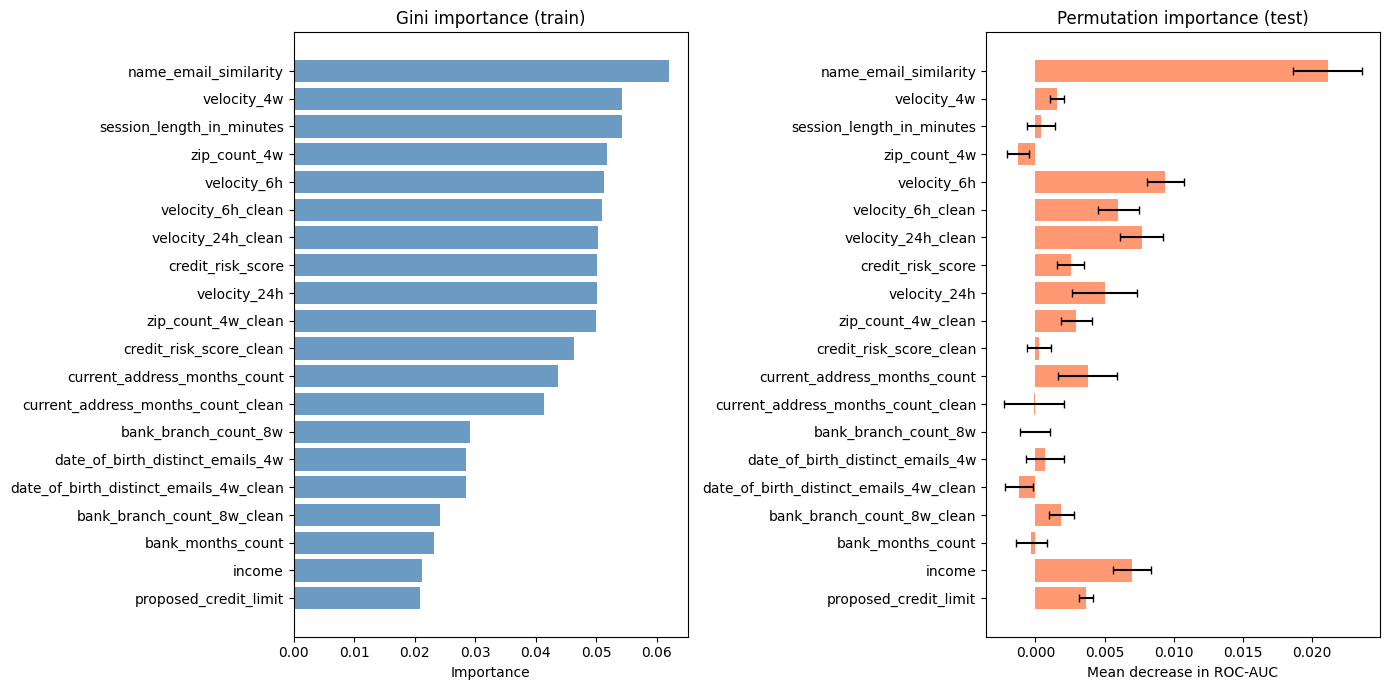

In [213]:
#визуализация
top20 = importance_combined.head(20).sort_values('Gini_train')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top20['Feature'], top20['Gini_train'], color='steelblue', alpha=0.8)
axes[0].set_title('Gini importance (train)')
axes[0].set_xlabel('Importance')

axes[1].barh(top20['Feature'], top20['Perm_test_mean'], color='coral', alpha=0.8)
axes[1].errorbar(
    top20['Perm_test_mean'], top20['Feature'],
    xerr=top20['Perm_test_std'],
    fmt='none', color='black', capsize=3
)
axes[1].set_title('Permutation importance (test)')
axes[1].set_xlabel('Mean decrease in ROC-AUC')

plt.tight_layout()
plt.show()

In [214]:
#Отбираем признаки с Gini на train > 0.001
selected_features = importance_combined[
    importance_combined['Gini_train'] > 0.001
]['Feature'].tolist()

print(f"Признаков до отбора: {X_train.shape[1]}")
print(f"Признаков после отбора: {len(selected_features)}")

# Флаг нестабильности: признак важен по Gini, но слаб на test
unstable = importance_combined[
    (importance_combined['Gini_train'] > 0.001) &
    (importance_combined['Perm_test_mean'] < 0)
]
if len(unstable) > 0:
    print(f"\nПризнаки с возможным переобучением ({len(unstable)} шт.):")
    print(unstable[['Feature', 'Gini_train', 'Perm_test_mean']].to_string(index=False))

Признаков до отбора: 53
Признаков после отбора: 47

Признаки с возможным переобучением (12 шт.):
                               Feature  Gini_train  Perm_test_mean
                          zip_count_4w    0.051851       -0.001264
    current_address_months_count_clean    0.041403       -0.000086
                  bank_branch_count_8w    0.029211       -0.000015
date_of_birth_distinct_emails_4w_clean    0.028403       -0.001176
                     bank_months_count    0.023245       -0.000291
                       payment_type_AB    0.005278       -0.000099
                       payment_type_AC    0.005233       -0.000012
                       payment_type_AD    0.004682       -0.000023
                     housing_status_BD    0.001830       -0.000060
                        source_TELEAPP    0.001437       -0.000023
                  employment_status_CD    0.001253       -0.000066
                         device_os_x11    0.001034       -0.000100


### Шаг 3 Корреляции

In [217]:
# корреляция всего с зависимой переменной
results = []
for col in df_train.select_dtypes(include=['float64', 'int64']).columns:
    if col == 'fraud_bool':
        continue
    corr, pval = stats.pointbiserialr(
        df_train['fraud_bool'],
        df_train[col].fillna(df_train[col].median())
    )
    results.append({
        'Feature': col,
        'PB_corr': round(corr, 4),
        'abs_corr': abs(corr),
        'p_value': round(pval, 6),
        'significant': pval < 0.05
    })

corr_df = pd.DataFrame(results).sort_values('abs_corr', ascending=False)
print(corr_df.to_string(index=False))

                               Feature  PB_corr  abs_corr  p_value  significant
                     credit_risk_score   0.0658  0.065805 0.000000         True
                 proposed_credit_limit   0.0645  0.064481 0.000000         True
                          customer_age   0.0639  0.063929 0.000000         True
               credit_risk_score_clean   0.0602  0.060177 0.000000         True
                    keep_alive_session  -0.0485  0.048539 0.000000         True
date_of_birth_distinct_emails_4w_clean  -0.0446  0.044553 0.000000         True
      date_of_birth_distinct_emails_4w  -0.0439  0.043870 0.000000         True
                                income   0.0426  0.042584 0.000000         True
    current_address_months_count_clean   0.0370  0.036984 0.000000         True
             device_distinct_emails_8w   0.0358  0.035844 0.000000         True
                 name_email_similarity  -0.0343  0.034317 0.000000         True
          current_address_months_count  

In [218]:
# убираем только те, что и слабые, и незначимые
weak_features = corr_df[
    (corr_df['abs_corr'] < 0.01) & (~corr_df['significant'])
]['Feature'].tolist()

print(f"Кандидаты на удаление: {weak_features}")

Кандидаты на удаление: ['intended_balcon_amount', 'velocity_4w', 'month']


In [219]:
# корреляция всего со всем
def calc_vif(X):
    X_filled = X.fillna(X.median())
    vif_data = pd.DataFrame({
        'Feature': X_filled.columns,
        'VIF': [variance_inflation_factor(X_filled.values, i)
                for i in range(X_filled.shape[1])]
    }).sort_values('VIF', ascending=False)
    return vif_data

# итеративно убираем признак с максимальным VIF пока все не станут < 10
X_vif = df_train.select_dtypes(include=['float64', 'int64']).drop(columns=['fraud_bool'])
removed = []

while True:
    vif = calc_vif(X_vif)
    max_vif = vif.iloc[0]
    if max_vif['VIF'] < 10:
        break
    print(f"Удаляем {max_vif['Feature']} (VIF={max_vif['VIF']:.1f})")
    removed.append(max_vif['Feature'])
    X_vif = X_vif.drop(columns=[max_vif['Feature']])

print(f"\nУдалено признаков: {len(removed)}: {removed}")
print(f"Осталось признаков: {X_vif.shape[1]}")

Удаляем velocity_24h_clean (VIF=294.0)
Удаляем date_of_birth_distinct_emails_4w_clean (VIF=93.4)
Удаляем velocity_6h_clean (VIF=91.7)
Удаляем credit_risk_score_clean (VIF=63.5)
Удаляем velocity_4w (VIF=60.6)
Удаляем device_distinct_emails_8w (VIF=21.4)
Удаляем velocity_24h (VIF=16.4)

Удалено признаков: 7: ['velocity_24h_clean', 'date_of_birth_distinct_emails_4w_clean', 'velocity_6h_clean', 'credit_risk_score_clean', 'velocity_4w', 'device_distinct_emails_8w', 'velocity_24h']
Осталось признаков: 25


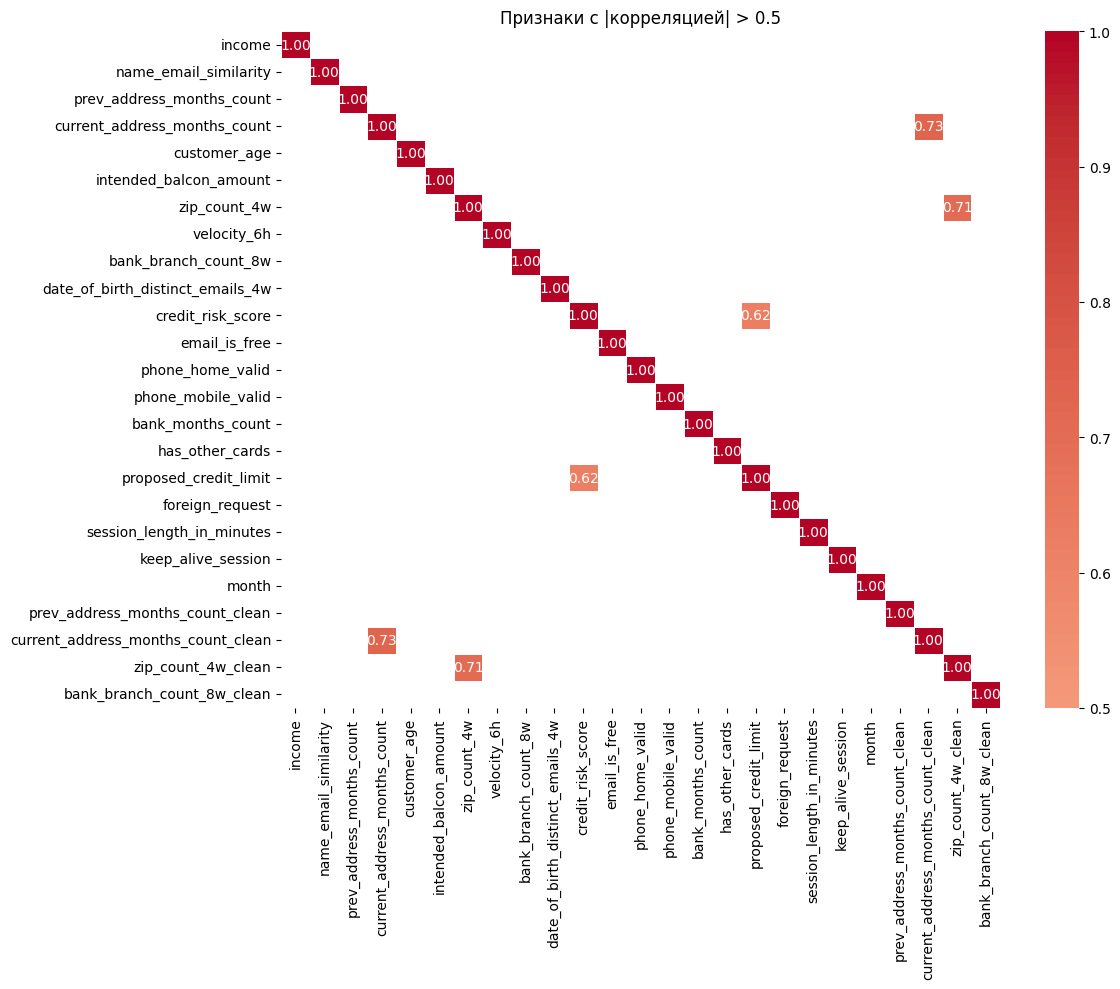

In [220]:
corr_matrix = X_vif.corr().abs()

# показываем только пары с |corr| > 0.5
mask = corr_matrix < 0.5
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=0.5, vmax=1.0,
    linewidths=0.5
)
plt.title('Признаки с |корреляцией| > 0.5')
plt.tight_layout()
plt.show()

##Итог

In [221]:
#собираем все списки исключений из предыдущих шагов

#после Джини
df_train = df_train[selected_features+ ['fraud_bool']]
df_train

,name_email_similarity,velocity_4w,session_length_in_minutes,zip_count_4w,velocity_6h,velocity_6h_clean,velocity_24h_clean,credit_risk_score,velocity_24h,zip_count_4w_clean,...,employment_status_CB,employment_status_CC,device_os_other,device_os_macintosh,housing_status_BE,housing_status_BD,source_TELEAPP,employment_status_CD,device_os_x11,fraud_bool
0,0.986506,6742.080561,16.224843,1059,13096.035018,13096.035018,7850.955007,163,7850.955007,1059.0,...,True,False,False,False,False,False,False,False,False,0
1,0.617426,5941.664859,3.363854,1658,9223.283431,9223.283431,5745.251481,154,5745.251481,1658.0,...,False,False,True,False,False,False,False,False,False,0
2,0.996707,5992.555113,22.730559,1095,4471.472149,4471.472149,5471.988958,89,5471.988958,1095.0,...,False,False,False,False,False,False,False,False,False,0
3,0.475100,5970.336831,15.215816,3483,14431.993621,14431.993621,6755.344479,90,6755.344479,3483.0,...,False,False,False,False,False,False,False,False,False,0
4,0.842307,5940.734212,3.743048,2339,7601.511579,7601.511579,5124.046930,91,5124.046930,2339.0,...,False,False,True,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675661,0.875923,4335.417808,6.307629,974,5463.487082,5463.487082,5032.752608,126,5032.752608,974.0,...,False,False,False,False,False,False,False,False,False,0
675662,0.246345,5564.518712,1.794107,1474,5184.182866,5184.182866,4927.757802,101,4927.757802,1474.0,...,False,False,False,False,False,False,False,False,False,0
675663,0.165010,5094.757332,4.797538,2999,4742.947511,4742.947511,4209.901207,86,4209.901207,2999.0,...,False,True,False,False,False,False,False,False,False,0
675664,0.377674,4700.024538,4.621124,4784,6985.294265,6985.294265,2593.162983,115,2593.162983,1359.0,...,True,False,False,False,False,False,False,False,False,0


In [224]:
#оставшиеся "грязные" переменные, если есть чистые в итоговом датасете
leftovers = ['current_address_months_count', 'bank_branch_count_8w', 'prev_address_months_count']

In [225]:
# корреляции с таргетом
dropped_low_corr = weak_features

# из мультиколлинеарности
dropped_multicoll = removed

all_dropped = (dropped_low_corr +
    dropped_multicoll
               +leftovers
)

# --- применяем только те, что реально есть в df ---
to_drop = [col for col in all_dropped if col in df_train.columns]
not_found = [col for col in all_dropped if col not in df_train.columns]


df_train = df_train.drop(columns=to_drop)

print(f"Удалено признаков:  {len(to_drop)}")
print(f"Осталось признаков: {df_train.shape[1] - 1}")  # -1 это таргет
print(f"\nФинальные признаки:")
final_features = [c for c in df_train.columns if c != 'fraud_bool']
for f in final_features:
    print(f"  {f}")

Удалено признаков:  3
Осталось признаков: 35

Финальные признаки:
  name_email_similarity
  session_length_in_minutes
  zip_count_4w
  velocity_6h
  credit_risk_score
  zip_count_4w_clean
  current_address_months_count_clean
  date_of_birth_distinct_emails_4w
  bank_branch_count_8w_clean
  bank_months_count
  income
  proposed_credit_limit
  customer_age
  device_os_windows
  email_is_free
  phone_home_valid
  keep_alive_session
  phone_mobile_valid
  housing_status_BC
  payment_type_AB
  payment_type_AC
  housing_status_BB
  foreign_request
  payment_type_AD
  has_other_cards
  prev_address_months_count_clean
  employment_status_CB
  employment_status_CC
  device_os_other
  device_os_macintosh
  housing_status_BE
  housing_status_BD
  source_TELEAPP
  employment_status_CD
  device_os_x11


In [226]:
final_features = [c for c in df_train.columns if c != 'fraud_bool']

# Применяем к val и oot — берём только те же колонки + таргет
df_test = df_test[final_features + ['fraud_bool']]
df_oot = df_oot[final_features + ['fraud_bool']]

In [227]:
final_features

['name_email_similarity',
 'session_length_in_minutes',
 'zip_count_4w',
 'velocity_6h',
 'credit_risk_score',
 'zip_count_4w_clean',
 'current_address_months_count_clean',
 'date_of_birth_distinct_emails_4w',
 'bank_branch_count_8w_clean',
 'bank_months_count',
 'income',
 'proposed_credit_limit',
 'customer_age',
 'device_os_windows',
 'email_is_free',
 'phone_home_valid',
 'keep_alive_session',
 'phone_mobile_valid',
 'housing_status_BC',
 'payment_type_AB',
 'payment_type_AC',
 'housing_status_BB',
 'foreign_request',
 'payment_type_AD',
 'has_other_cards',
 'prev_address_months_count_clean',
 'employment_status_CB',
 'employment_status_CC',
 'device_os_other',
 'device_os_macintosh',
 'housing_status_BE',
 'housing_status_BD',
 'source_TELEAPP',
 'employment_status_CD',
 'device_os_x11']

In [228]:
#выгрузим итоговые таблицы
df_train.to_csv('df_train.csv', index=False)
df_test.to_csv('df_test.csv', index=False)
df_oot.to_csv('df_oot.csv', index=False)

print(f"df_train.csv — {df_train.shape[0]:,} строк, {df_train.shape[1]} колонок")
print(f"df_test.csv — {df_test.shape[0]:,} строк, {df_test.shape[1]} колонок")
print(f"df_test.csv        — {df_oot.shape[0]:,} строк, {df_oot.shape[1]} колонок")
print(f"\nПризнаки: {[c for c in df_train.columns if c != 'fraud_bool']}")

df_train.csv — 675,666 строк, 36 колонок
df_test.csv — 119,323 строк, 36 колонок
df_test.csv        — 205,011 строк, 36 колонок

Признаки: ['name_email_similarity', 'session_length_in_minutes', 'zip_count_4w', 'velocity_6h', 'credit_risk_score', 'zip_count_4w_clean', 'current_address_months_count_clean', 'date_of_birth_distinct_emails_4w', 'bank_branch_count_8w_clean', 'bank_months_count', 'income', 'proposed_credit_limit', 'customer_age', 'device_os_windows', 'email_is_free', 'phone_home_valid', 'keep_alive_session', 'phone_mobile_valid', 'housing_status_BC', 'payment_type_AB', 'payment_type_AC', 'housing_status_BB', 'foreign_request', 'payment_type_AD', 'has_other_cards', 'prev_address_months_count_clean', 'employment_status_CB', 'employment_status_CC', 'device_os_other', 'device_os_macintosh', 'housing_status_BE', 'housing_status_BD', 'source_TELEAPP', 'employment_status_CD', 'device_os_x11']
